# Part I: From VGG to ResNet
Implement and compare VGG-16 (Version C) and ResNet-18 for image classification. Explore advanced techniques to improve model performance and the transition from standard deep CNNs to networks with residual connections.

## Step 1: Data preparation

In [1]:
!pip install torchsummary

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/cvmfs/soft.ccr.buffalo.edu/versions/2023.01/easybuild/software/avx512/Compiler/gcccore/11.2.0/python/3.9.6/bin/python3.9 -m pip install --upgrade pip' command.


In [37]:
import torchvision
print(torchvision.__version__)


0.18.1a0


In [38]:
import torch
from torchvision.datasets import ImageFolder
from torchvision import transforms as T
from torch.utils.data import DataLoader, Subset ,Dataset
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import seaborn as sns

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import json
import time
import copy

from tqdm import tqdm

from sklearn.metrics import precision_score, recall_score, f1_score , accuracy_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve , auc
from sklearn.preprocessing import label_binarize

from torchsummary import summary

import random

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.mps.is_available() else "cpu")
device

'cpu'

In [39]:
seed = 18
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

Load CNN dataset.

In [40]:
transform = T.Compose([
    T.Resize((224, 224), antialias=True),    
    T.ToTensor(),  
    T.ConvertImageDtype(torch.float32),  
])

dataset = ImageFolder(root='./cnn_dataset', transform=transform)


Analyze the dataset.

In [5]:
print("Classes: ", dataset.classes)
print("Number of data: ", len(dataset))
labels = dataset.targets
labels_counts = Counter(labels)
print("Number of data per label: ", labels_counts)

Classes:  ['dogs', 'food', 'vehicles']
Number of data:  30000
Number of data per label:  Counter({0: 10000, 1: 10000, 2: 10000})


<span>The CNN dataset consists of 30,000 images. The labels are divided into three classes (0: 'dogs', 1: 'food', 2:'vehicles') and the data is evenly distributed into 10,000 images each.</span>

Visualize the dataset

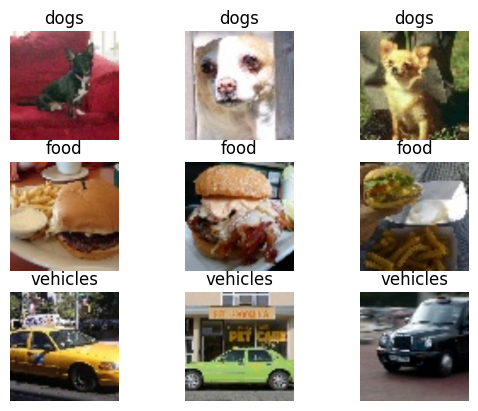

In [6]:
# 1. Grid of sample images
sample_indices = [0, 1, 2, 10000, 10001, 10002, 20000, 20001, 20002]
for i in range(len(sample_indices)):
    img, label = dataset[sample_indices[i]]
    plt.subplot(3,3,i+1)
    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.title(dataset.classes[int(label)])
    plt.axis('off')
plt.show()

Text(0.5, 1.0, 'Number of images per class')

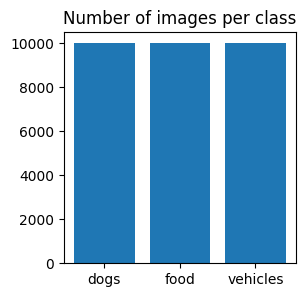

In [7]:
# 2. Bar chart showing the number of images per class
plt.figure(figsize=(3, 3))
plt.bar(labels_counts.keys(), labels_counts.values())
plt.xticks(range(len(dataset.classes)), dataset.classes)
plt.title("Number of images per class")

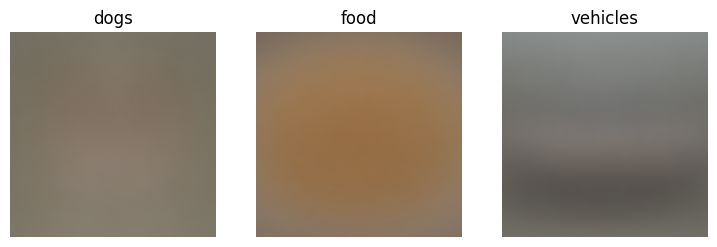

In [7]:
# 3. Average image for each class
average_img = {0: None, 1: None, 2: None}
for img, label in dataset:
   if average_img[label] is None:
      average_img[label] = torch.zeros_like(img)
   average_img[label] += img.float()

for label, img in average_img.items():
   average_img[label] = img/10000

plt.figure(figsize=(9, 3))
for label, img in average_img.items():
  plt.subplot(1,3,label+1)
  plt.imshow(img.permute(1, 2, 0).numpy())
  plt.title(dataset.classes[int(label)])
  plt.axis('off')
plt.show()

<ul>
    <li>Grid of sample images: Shows example images from each class. </li>
    <li>Bar chart showing the number of images per class: Illustrates that the dataset is evenly balanced across the classes.</li>
    <li>Average image for each class: Reveals distinct color patterns characteristic of each category.</li>
</ul>

Preprocess the dataset.

In [8]:
# Normalized the pixel values during loading the dataset.
print("Min pixel value:", dataset[0][0].min().item())
print("Max pixel value:",dataset[0][0].max().item())


Min pixel value: 0.0117647061124444
Max pixel value: 1.0


In [64]:
indices = [i for i in range(len(dataset))]
train_indices, test_indices = train_test_split(indices, test_size=0.1, stratify=labels)
train_indices, val_indices = train_test_split(train_indices, test_size=0.11, stratify=np.array(labels)[train_indices])
train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Step 2: Implementing VGG

Implement the VGG-16 (Version C) architecture.

In [10]:
class VGG16(nn.Module):
    def __init__(self, num_classes, init_method=None):
        super(VGG16, self).__init__()
        nn.Conv3d
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer5 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, num_classes)
        )

        self.init_weights(init_method)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
    
    def init_weights(self, init_method=None):
        if init_method is None:
            return
        
        for module in self.modules():
            if not isinstance(module, nn.Conv2d) and not isinstance(module, nn.Linear):
                continue
            if init_method == 'xavier':
                nn.init.xavier_uniform_(module.weight)
            elif init_method == 'he':
                nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')

In [11]:
vgg16 = VGG16(num_classes=3)
summary(vgg16, input_size=(3, 224, 224) , device = 'cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

Experiment with weight initialization strategies.

In [11]:
# Experiment is below
vgg16_xavier = VGG16(num_classes=3, init_method='xavier')
vgg16_he = VGG16(num_classes=3, init_method='he')

Train VGG-16 model.

In [12]:
def train_one_epoch(model , train_loader  , optimizer , loss_function   ):
    model.train()
    
    epoch_loss = 0.0
    correct_pred = 0
    total_pred = 0
    
    
    for i , (images , labels) in tqdm(enumerate(train_loader)):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        #print( outputs.shape , labels.shape)
        loss = loss_function(outputs , labels)
        
        loss.backward()
        optimizer.step()
        
        
        epoch_loss += loss.item()
        _,pred = torch.max(outputs , 1)
        correct_pred += (pred == labels).sum().item()
        total_pred += labels.size(0)
        
        
    optimizer.step()
    optimizer.zero_grad()
    
    
    # Average loss
    avg_train_loss = epoch_loss/len(train_loader)
    train_acc = correct_pred / total_pred
    
    print(f"Training loss { avg_train_loss} | accuracy {train_acc} ")
    
    return avg_train_loss,train_acc

In [13]:
def val(model , loader , loss_function ):
    model.eval()
    
    curr_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(loader):
            images, labels = images.to(device), labels.to(device)

            output = model(images)
            #print(output.shape , labels.shape)
            batch_loss = loss_function(output , labels)
            
            curr_loss += batch_loss.item()
            _,pred = torch.max(output , 1)
            
            correct += (pred == labels).sum().item()
            total += labels.size(0)
            
        
    epoch_loss = curr_loss/len(loader)
    acc = correct/total
    
    print(f"validation loss { epoch_loss} | accuracy {acc} ")

    return epoch_loss , acc
            

#eval(model , val_loader , criterion , device)

In [14]:
def train(model , train_loader , val_loader , epochs , optimizer , loss_function , training_details , best_model_path, scheduler=None, early_stopping=False):
    
    train_loss_list = []
    val_loss_list = []
    val_acc_list = []
    train_acc_list = []
    lr_reduction = 0
    
    best_val_acc = 0.0
    #best_model_path = 'best_model.pth'
    
    start_time = time.time()
    
    for epoch in range(epochs):
        print("\n\n\n********************************************")
        print(f"Epoch :{epoch + 1}")
        print(f"Learning Rate {optimizer.param_groups[0]['lr']}")
        train_loss,train_acc = train_one_epoch(
                                        model=model,
                                        train_loader=train_loader,
                                        optimizer=optimizer,
                                        loss_function=loss_function,
                                        )
        
        
        val_loss, val_acc = val(
                                model=model,
                                loader=val_loader,
                                loss_function=loss_function        
                            )
        if scheduler is not None:
            prev_lr = optimizer.param_groups[0]['lr']
            scheduler.step(val_acc)
            current_lr = optimizer.param_groups[0]['lr']
            if current_lr < prev_lr:
                lr_reduction += 1

        print(f"Learning Rate {optimizer.param_groups[0]['lr']}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)  # Save best model    
            print(f"New best model saved at epoch {epoch+1} with validation accuracy {val_acc:.4f}")
    
        train_loss_list.append(train_loss)
        val_loss_list.append(val_loss)
        val_acc_list.append(train_acc)
        train_acc_list.append(val_acc)
        
        training_file_name = best_model_path.split(".")[0]+".txt"
        
        with open(training_file_name, 'w') as file:
            json.dump(training_details, file)
        
        if scheduler is not None and early_stopping is True and lr_reduction >= 3:
            print("Early Stopping: Stop training because the learning rate has decreased 3 times.")
            break
        
    end_time = time.time()    
    
    print(f"\nExecution Time: {(end_time-start_time):.6f} seconds")
    
    training_details["train_acc"].extend(train_acc_list)
    training_details["val_acc"].extend(val_acc_list)
    training_details["train_loss"].extend(train_loss_list)
    training_details["val_loss"].extend(val_loss_list)

In [43]:
def evaluate(model , test_loader , loss_function ):
    y_true = []
    y_pred = []

    curr_loss = 0

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Testing", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            batch_loss = loss_function(outputs , labels)
            curr_loss += batch_loss.item()
            _, predicted = torch.max(outputs, 1)
            y_pred.extend(list(predicted.cpu().numpy()))
            y_true.extend(list(labels.cpu().numpy()))
            
        epoch_loss = curr_loss/len(test_loader)
        acc = accuracy_score(y_true,y_pred)
        precision = precision_score(y_true, y_pred, average='weighted')
        recall = recall_score(y_true, y_pred, average='weighted')
        f1 = f1_score(y_true, y_pred, average='weighted')

        print(f"Loss : {epoch_loss} | Acc : {acc}")
        print(f'Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')

    return y_true , y_pred , epoch_loss , acc 
            
def plot_loss(training_details , test_loss):
    train_loss_list = training_details["train_loss"]
    val_loss_list = training_details["val_loss"]
    #test_loss = test_loss

    plt.figure(figsize=(20, 6))
    epochs = range(1, len(train_loss_list) + 1)
    test_loss_list = [test_loss] * len(epochs)

    plt.plot(epochs, train_loss_list, label='Training Loss', marker='o')
    plt.plot(epochs, val_loss_list, label='Validation Loss', marker='o')
    plt.plot(epochs, test_loss_list, label='Test Loss', color='red', linestyle='--')

    plt.title('Training, Validation, and Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')


    plt.legend()
    plt.grid()
    plt.xticks()
    plt.show()
    
def plot_accuracy(training_details , test_acc):
    train_acc_list = training_details["train_acc"]
    val_acc_list = training_details["val_acc"]
    test_accuracy = test_acc

    plt.figure(figsize=(20, 6))
    test_acc_list = [test_accuracy] * len(train_acc_list)
    epochs = range(1, len(train_acc_list) + 1)

    plt.plot(epochs, train_acc_list, label='Training Accuracy', marker='o')
    plt.plot(epochs, val_acc_list, label='Validation Accuracy', marker='o')
    plt.plot(epochs, test_acc_list, label='Test Accuracy', linestyle='--')

    plt.title('Training, Validation, and Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    plt.legend()
    plt.grid()
    plt.xticks()
    plt.show()
    
def plot_conf_mat(y_true , y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(np.arange(4) , ["c0" , "c1" , "c2", "c3" ]  )
    plt.yticks(np.arange(4) , ["c0" , "c1" , "c2", "c3" ] )
    plt.title('Confusion Matrix')
    plt.show()

def plot_roc_curve(y_true , y_pred):
    classes = np.unique(np.concatenate((y_true, y_pred)))
    y_true_bin = label_binarize(y_true, classes=classes)
    y_pred_bin = label_binarize(y_pred, classes=classes)
    n_classes = len(classes)

    # Calculate ROC curves and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot the ROC curves for each class
    plt.figure(figsize=(12,8))
    colors = plt.cm.get_cmap('tab20', n_classes)

    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], color=colors(i), lw=2, label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')  # Diagonal line for random guess
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve')
    plt.legend(bbox_to_anchor=(1.35, 0.5))
    plt.grid(True)
    plt.show()
    

In [16]:
num_epochs = 30
learning_rate = 0.01
criterion = nn.CrossEntropyLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("mps" if torch.mps.is_available() else "cpu")

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Experiment with Weight Initialization Strategies
1. xavier
2. he

In [22]:
# 1. xavier
vgg16_xavier = VGG16(num_classes=3, init_method='xavier')
vgg16_xavier = vgg16_xavier.to(device)
optimizer = optim.SGD(vgg16_xavier.parameters(), lr=learning_rate, momentum=0.9)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=1)

training_details = {}
training_details["train_acc"] = []
training_details["val_acc"] = []
training_details["train_loss"] = []
training_details["val_loss"] = [] 
BEST_MODEL_PATH = "best_model_xavier.pth"

train(
    model=vgg16_xavier,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    best_model_path=BEST_MODEL_PATH,
    scheduler = scheduler
    )

with open('training_details_vgg16_xe.txt', 'w') as file:
    json.dump(training_details, file)




********************************************
Epoch :1
Learning Rate 0.01


188it [01:49,  1.71it/s]


Training loss 1.0923230505370078 | accuracy 0.37494798168955473 


100%|██████████| 24/24 [00:08<00:00,  2.97it/s]


validation loss 1.1003237664699554 | accuracy 0.3333333333333333 
Learning Rate 0.01
New best model saved at epoch 1 with validation accuracy 0.3333



********************************************
Epoch :2
Learning Rate 0.01


...

validation loss 0.3134194544206063 | accuracy 0.9107744107744108 
Learning Rate 1.0000000000000004e-08



********************************************
Epoch :30
Learning Rate 1.0000000000000004e-08


188it [02:10,  1.45it/s]


Training loss 0.05913252700516518 | accuracy 0.9805243445692884 


100%|██████████| 24/24 [00:11<00:00,  2.13it/s]

validation loss 0.3134230151772499 | accuracy 0.9107744107744108 
Learning Rate 1.0000000000000004e-08

Execution Time: 3765.967312 seconds


In [23]:
vgg16_xavier.load_state_dict(torch.load(BEST_MODEL_PATH))
y_true , y_pred , test_loss , test_acc  = evaluate(vgg16_xavier , test_loader , criterion)

Loss : 0.3525813345777545 | Acc : 0.903
Precision: 0.9032, Recall: 0.9030, F1 Score: 0.9031


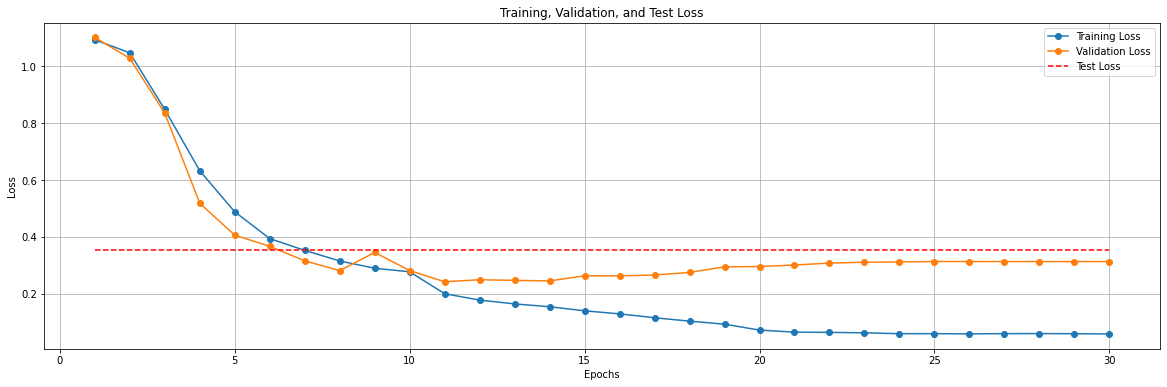

In [24]:
plot_loss(training_details , test_loss)

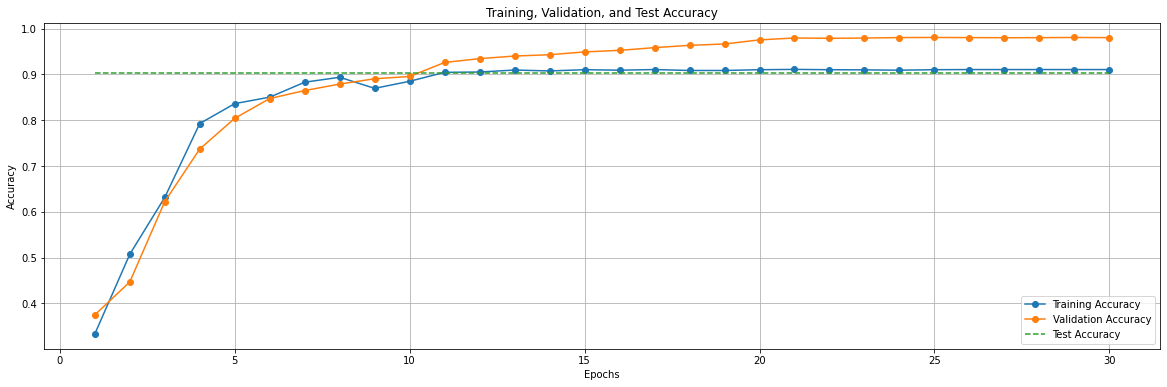

In [25]:
plot_accuracy(training_details , test_acc)

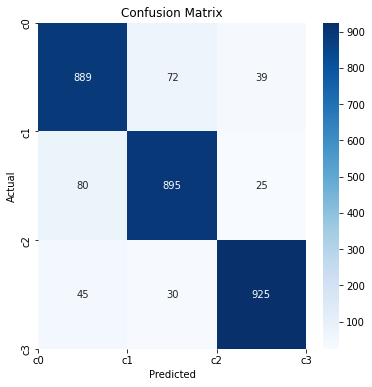

In [26]:
plot_conf_mat(y_true , y_pred)

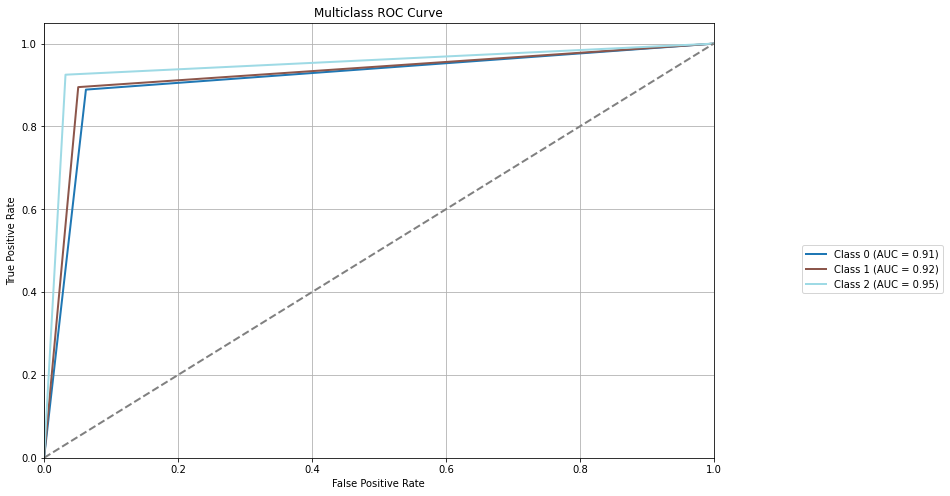

In [27]:
plot_roc_curve(y_true , y_pred)

In [25]:
# 2. he

vgg16_he = vgg16_he.to(device)
optimizer = optim.SGD(vgg16_he.parameters(), lr=learning_rate, momentum=0.9)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=1)

training_details = {}
training_details["train_acc"] = []
training_details["val_acc"] = []
training_details["train_loss"] = []
training_details["val_loss"] = [] 
BEST_MODEL_PATH = "best_model_he.pth"
train(
    model=vgg16_he,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    best_model_path=BEST_MODEL_PATH,
    scheduler = scheduler
    )

with open('training_details_vgg16_he.txt', 'w') as file:
    json.dump(training_details, file)




********************************************
Epoch :1
Learning Rate 0.01


188it [01:50,  1.70it/s]


Training loss 0.9856270837022904 | accuracy 0.5057428214731585 


100%|██████████| 24/24 [00:08<00:00,  2.78it/s]


validation loss 0.8557313804825147 | accuracy 0.6124579124579125 
Learning Rate 0.01
New best model saved at epoch 1 with validation accuracy 0.6125



********************************************
Epoch :2
Learning Rate 0.01


...

188it [02:14,  1.40it/s]


Training loss 0.14783429794330546 | accuracy 0.9454431960049937 


100%|██████████| 24/24 [00:11<00:00,  2.01it/s]


validation loss 0.19975855853408575 | accuracy 0.9255892255892256 
Learning Rate 1.0000000000000002e-06



********************************************
Epoch :24
Learning Rate 1.0000000000000002e-06


16it [00:11,  1.38it/s]IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [26]:
vgg16_he.load_state_dict(torch.load(BEST_MODEL_PATH))
y_true , y_pred , test_loss , test_acc  = evaluate(vgg16_he , test_loader , criterion)

Loss : 0.2158181768188134 | Acc : 0.9236666666666666
Precision: 0.9238, Recall: 0.9237, F1 Score: 0.9237


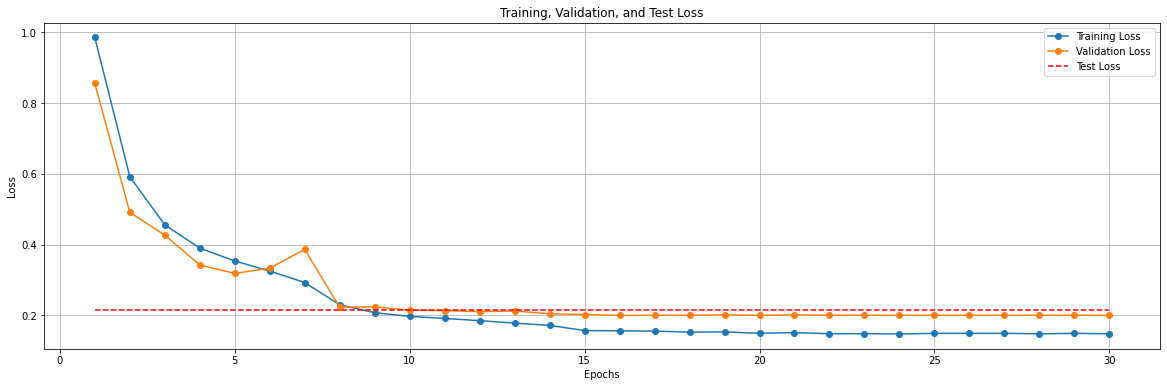

In [27]:
plot_loss(training_details , test_loss)

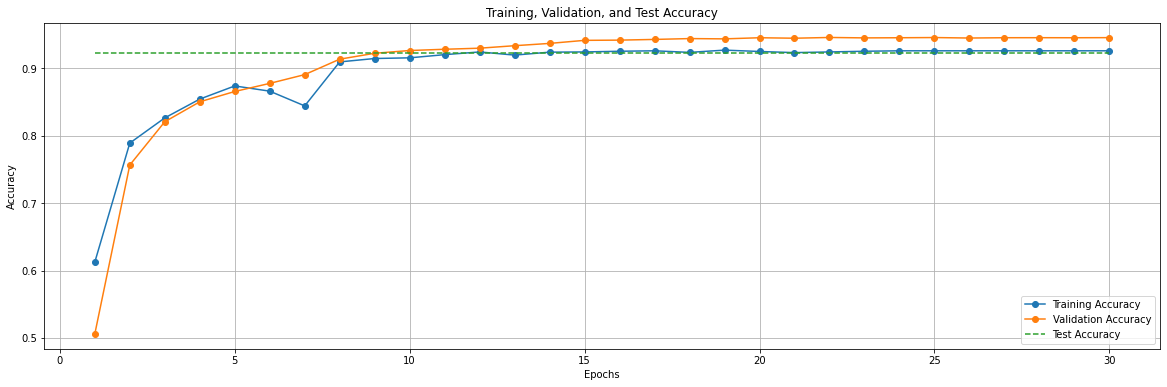

In [28]:
plot_accuracy(training_details , test_acc)

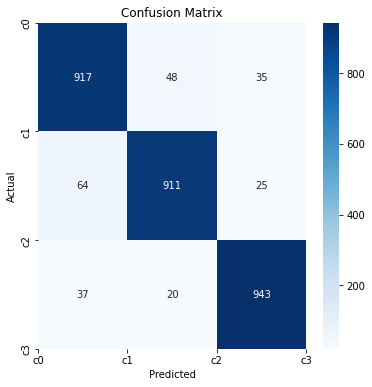

In [29]:
plot_conf_mat(y_true , y_pred)

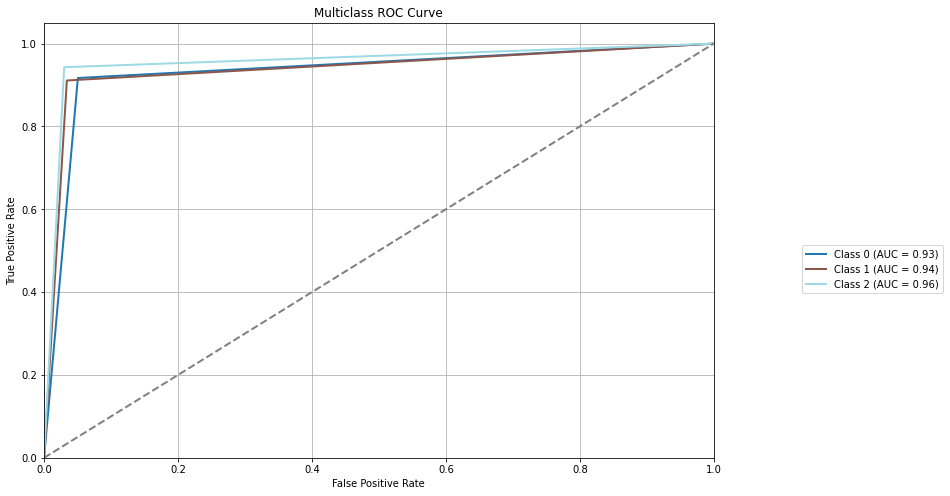

In [30]:
plot_roc_curve(y_true , y_pred)

Weight Initialization Strategies Experiment Result 
- Convergence speed: A model with He initialization shows faster convergence in training loss and more stable accuracy curves.
- Learning curves: The Xavier-initialized model has a larger gap between training and validation curves, whereas the He-initialized model ahieves similar test results.
- He initialization helps the VGG model train more effectively.

Experiment with Optimizers
1. SGD
2. Adam
3. RMSprop

In [16]:
num_epochs = 30
learning_rate = 0.01
criterion = nn.CrossEntropyLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("mps" if torch.mps.is_available() else "cpu")

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [17]:
# 2. Adam

vgg16_adam = VGG16(num_classes=3 , init_method='he').to(device)
optimizer = optim.Adam(vgg16_adam.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=1)

training_details = {}
training_details["train_acc"] = []
training_details["val_acc"] = []
training_details["train_loss"] = []
training_details["val_loss"] = [] 
BEST_MODEL_PATH = "best_model_adam.pth"

train(
    model=vgg16_adam,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    best_model_path=BEST_MODEL_PATH,
    scheduler = scheduler,
    early_stopping=True
    )

with open('training_details_vgg16_adam.txt', 'w') as file:
    json.dump(training_details, file)




********************************************
Epoch :1
Learning Rate 0.01


376it [08:23,  1.34s/it]


Training loss 7222246.247325083 | accuracy 0.3303370786516854 


100%|██████████| 47/47 [00:26<00:00,  1.78it/s]


validation loss 1.098807045753966 | accuracy 0.3333333333333333 
Learning Rate 0.01
New best model saved at epoch 1 with validation accuracy 0.3333



********************************************
Epoch :2
Learning Rate 0.01


...

validation loss 1.0986366627064157 | accuracy 0.3333333333333333 
Learning Rate 0.0001



********************************************
Epoch :7
Learning Rate 0.0001


376it [08:19,  1.33s/it]


Training loss 1.0987690363792664 | accuracy 0.33374947981689557 


100%|██████████| 47/47 [00:24<00:00,  1.91it/s]

validation loss 1.0986295050763069 | accuracy 0.3333333333333333 
Learning Rate 1e-05
Early Stopping: Stop training because the learning rate has decreased 3 times.

Execution Time: 3672.974233 seconds


In [18]:
vgg16_adam.load_state_dict(torch.load(BEST_MODEL_PATH))
y_true , y_pred , test_loss , test_acc  = evaluate(vgg16_adam , test_loader , criterion)

Loss : 1.098767009187252 | Acc : 0.3333333333333333
Precision: 0.1111, Recall: 0.3333, F1 Score: 0.1667



/user/shubham/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


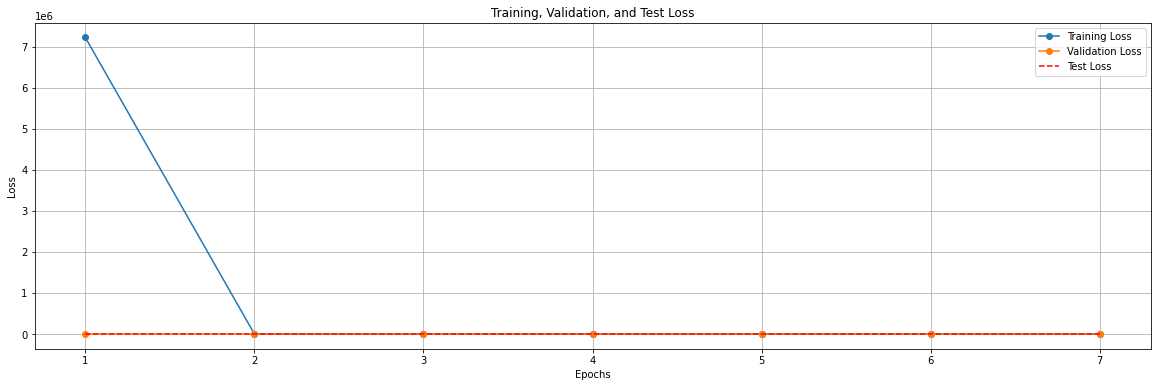

In [19]:
plot_loss(training_details , test_loss)

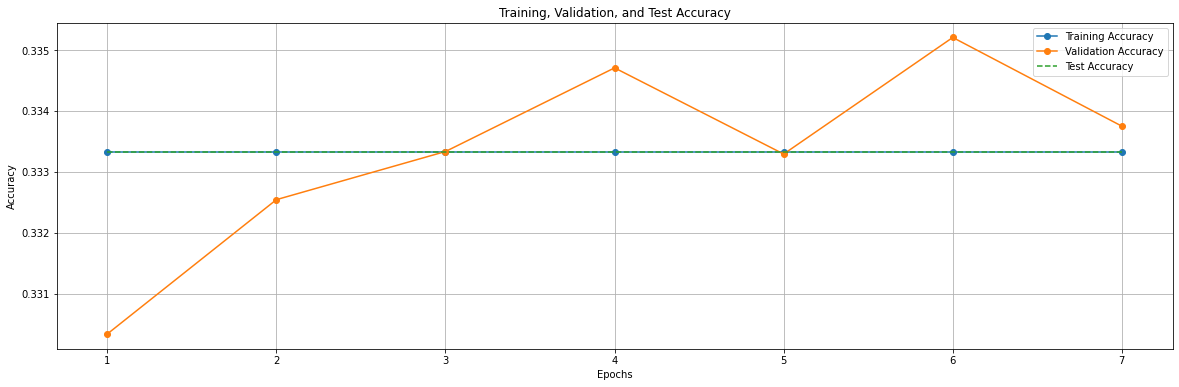

In [20]:
plot_accuracy(training_details , test_acc)

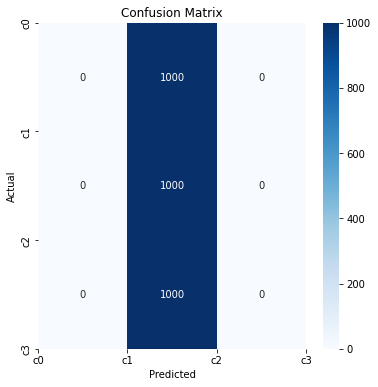

In [21]:
plot_conf_mat(y_true , y_pred)

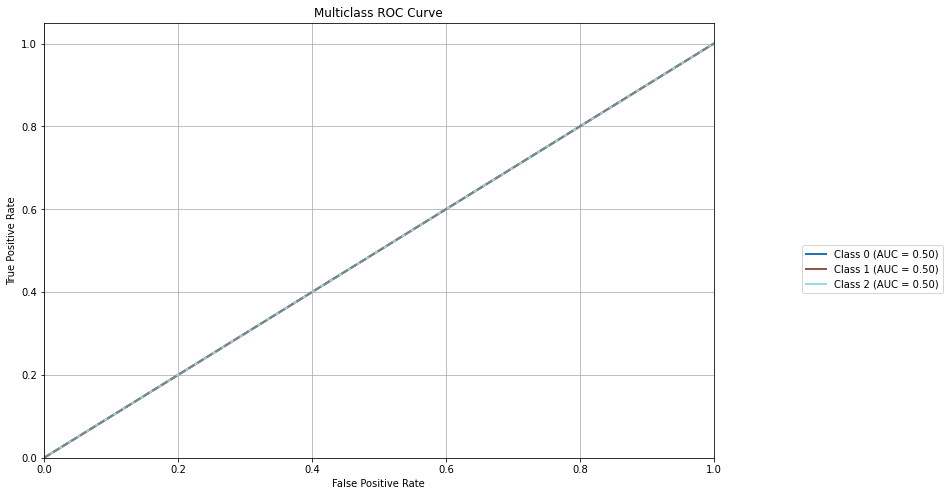

In [22]:
plot_roc_curve(y_true , y_pred)

In [18]:
# 3. RMSprop

vgg16_rms = VGG16(num_classes=3, init_method='he').to(device)
optimizer = optim.RMSprop(vgg16_rms.parameters(), lr=learning_rate, momentum=0.9)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=1)
BEST_MODEL_PATH = "best_model_rms.pth"


In [23]:

training_details = {}
training_details["train_acc"] = []
training_details["val_acc"] = []
training_details["train_loss"] = []
training_details["val_loss"] = [] 
BEST_MODEL_PATH = "best_model_rms.pth"

train(
    model=vgg16_rms,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    best_model_path=BEST_MODEL_PATH,
    scheduler = scheduler,
    early_stopping=True
    )

with open('training_details_vgg16_rms.txt', 'w') as file:
    json.dump(training_details, file)




********************************************
Epoch :1
Learning Rate 0.01


376it [08:18,  1.33s/it]


Training loss 1.1302307183472877e+32 | accuracy 0.33429047024552644 


100%|██████████| 47/47 [00:24<00:00,  1.91it/s]


validation loss 1.232868431881284e+32 | accuracy 0.3333333333333333 
Learning Rate 0.01
New best model saved at epoch 1 with validation accuracy 0.3333



********************************************
Epoch :2
Learning Rate 0.01


...

validation loss 1.2328685903277318e+32 | accuracy 0.3333333333333333 
Learning Rate 0.0001



********************************************
Epoch :7
Learning Rate 0.0001


376it [08:17,  1.32s/it]


Training loss 1.2573859501075475e+32 | accuracy 0.333458177278402 


100%|██████████| 47/47 [00:24<00:00,  1.90it/s]

validation loss 1.2328685862122396e+32 | accuracy 0.3333333333333333 
Learning Rate 1e-05
Early Stopping: Stop training because the learning rate has decreased 3 times.

Execution Time: 3660.746772 seconds


In [22]:
vgg16_rms.load_state_dict(torch.load(BEST_MODEL_PATH))
with open('training_details_vgg16_rms.txt', 'r') as file:
    training_details = json.load(file)


y_true , y_pred , test_loss , test_acc  = evaluate(vgg16_rms , test_loader , criterion)

Loss : 1.2118805006800783e+32 | Acc : 0.333
Precision: 0.1667, Recall: 0.3330, F1 Score: 0.1672



/user/shubham/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


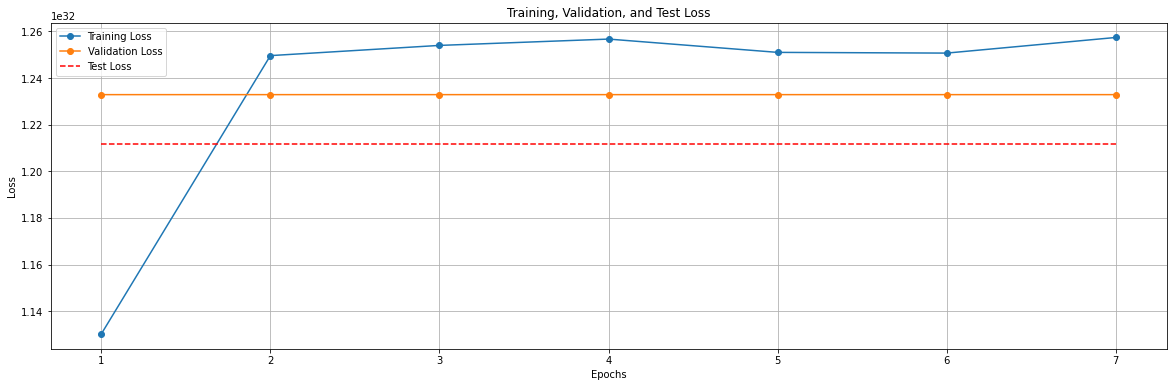

In [23]:
plot_loss(training_details , test_loss)

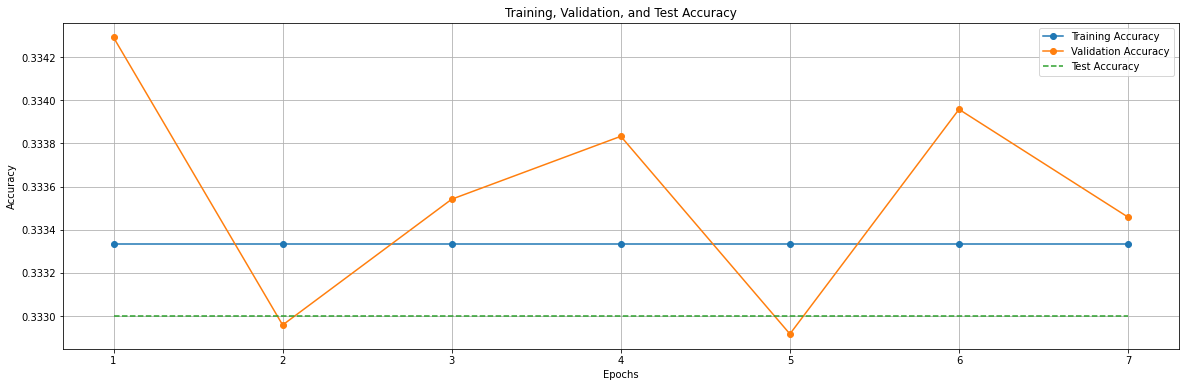

In [24]:
plot_accuracy(training_details , test_acc)

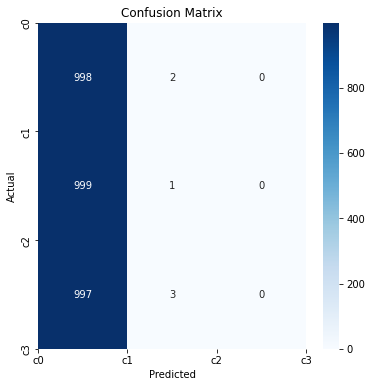

In [25]:
plot_conf_mat(y_true , y_pred)

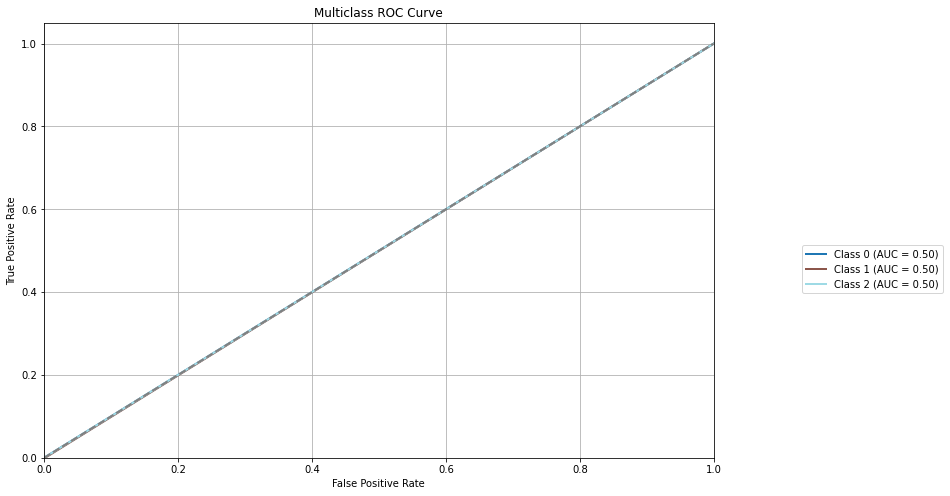

In [26]:
plot_roc_curve(y_true , y_pred)

Optimizer Experiment Result
- Compared to Adam and RMSprop, SGD produces more stable convergence curves for both training and validation.
- In the confusion matrices for Adam and RMSprop, most samples end up classified into the same class.
- Overall, SGD achieves notably better performance in this setup.
For deeper networks like VGG, SGD appears to be a more suitable optimizer.

Experiment with batch sizes
1. 128
2. 64


In [27]:
# 2. 64

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [28]:
vgg16_64 = VGG16(num_classes=3, init_method='he').to(device)
optimizer = optim.SGD(vgg16_64.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=1)

training_details = {}
training_details["train_acc"] = []
training_details["val_acc"] = []
training_details["train_loss"] = []
training_details["val_loss"] = [] 
BEST_MODEL_PATH = "best_model_b64.pth"

train(
    model=vgg16_64,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    best_model_path=BEST_MODEL_PATH,
    scheduler = scheduler,
    early_stopping=True
    )

with open('training_details_vgg16_64.txt', 'w') as file:
    json.dump(training_details, file)




********************************************
Epoch :1
Learning Rate 0.01


376it [02:06,  2.98it/s]


Training loss 0.9383922236713957 | accuracy 0.5760299625468165 


100%|██████████| 47/47 [00:13<00:00,  3.42it/s]


validation loss 1.089921180238115 | accuracy 0.49764309764309766 
Learning Rate 0.01
New best model saved at epoch 1 with validation accuracy 0.4976



********************************************
Epoch :2
Learning Rate 0.01


...

validation loss 0.21939873132616916 | accuracy 0.9188552188552188 
Learning Rate 0.0001



********************************************
Epoch :20
Learning Rate 0.0001


376it [01:34,  3.99it/s]


Training loss 0.16468877419631214 | accuracy 0.9395755305867666 


100%|██████████| 47/47 [00:09<00:00,  4.77it/s]

validation loss 0.21962662936842187 | accuracy 0.9191919191919192 
Learning Rate 1e-05
Early Stopping: Stop training because the learning rate has decreased 3 times.

Execution Time: 2089.036785 seconds


In [29]:
vgg16_64.load_state_dict(torch.load(BEST_MODEL_PATH))
y_true , y_pred , test_loss , test_acc  = evaluate(vgg16_64 , test_loader , criterion)

Loss : 0.22184306795292713 | Acc : 0.9193333333333333
Precision: 0.9196, Recall: 0.9193, F1 Score: 0.9194


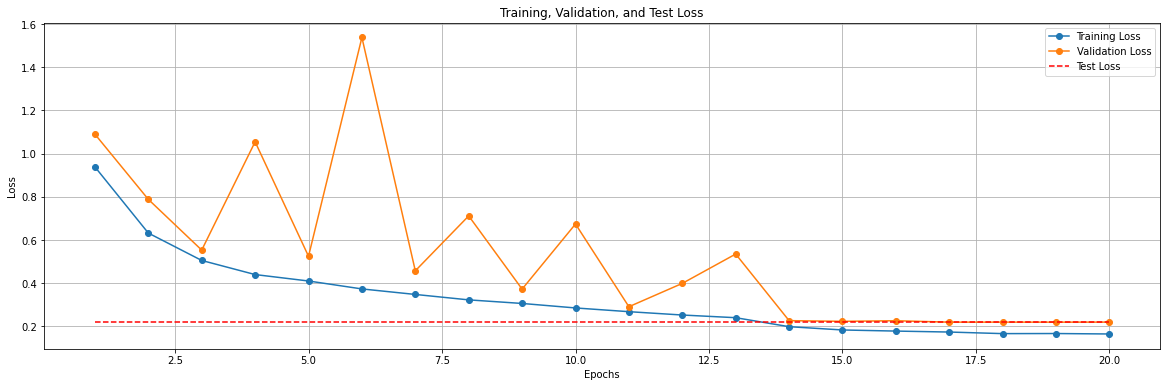

In [30]:
plot_loss(training_details , test_loss)

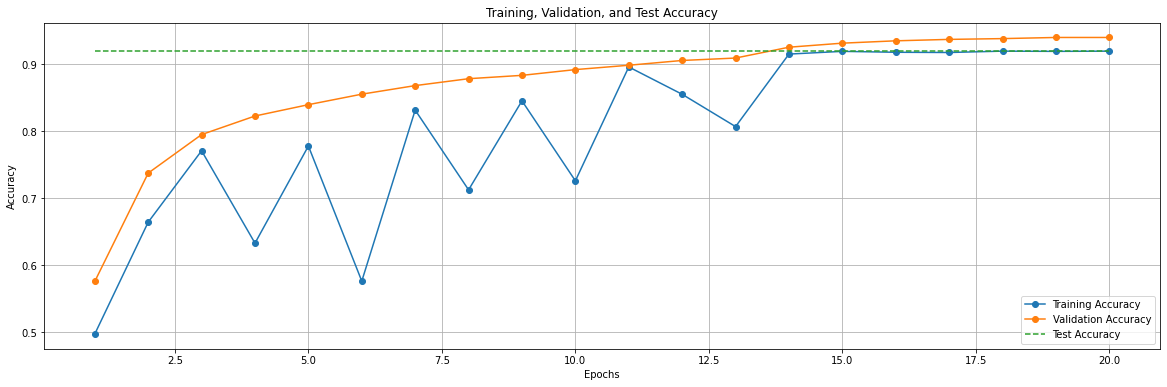

In [31]:
plot_accuracy(training_details , test_acc)

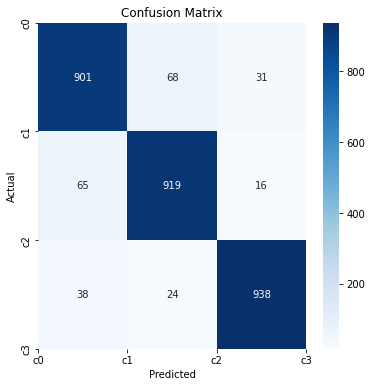

In [32]:
plot_conf_mat(y_true , y_pred)

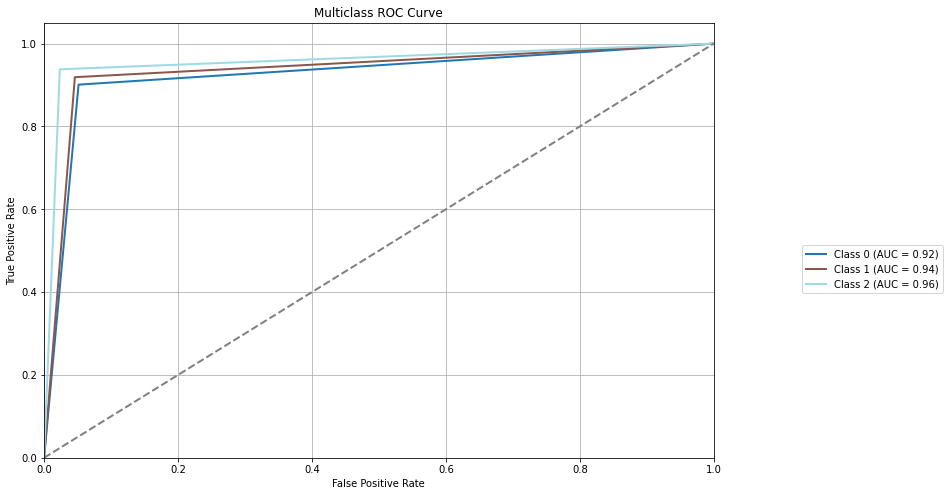

In [33]:
plot_roc_curve(y_true , y_pred)

Batch Size Experiment Result
- Both batch sizes achive strong test performance.
- Batch size 64 leads to more fluctuations during training, while a batch size of 32 shows smoother learning curves.

Best Model and Methods
- Weight Initialization Strategy: He
- Optimizer: SGD
- Batch Size: 64/128

Apply regularization and overfitting prevention techniques.
- using best model and methods above

In [42]:
# 1. Regularization

class VGG16_Reg(nn.Module):
    def __init__(self, num_classes, init_method=None):
        super(VGG16_Reg, self).__init__()
        nn.Conv3d
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer5 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, num_classes)
        )

        self.init_weights(init_method)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
    
    def init_weights(self, init_method=None):
        if init_method is None:
            return
        for module in self.modules():
            if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
                if hasattr(module, "weight") and module.weight is not None:
                    if init_method == "xavier":
                        nn.init.xavier_uniform_(module.weight)
                    elif init_method == "he":
                        nn.init.kaiming_uniform_(module.weight, nonlinearity="relu")
                if hasattr(module, "bias") and module.bias is not None:
                    nn.init.constant_(module.bias, 0)

In [18]:
vgg16_reg = VGG16_Reg(num_classes=3, init_method='he').to(device)
summary(vgg16_reg, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
       BatchNorm2d-2         [-1, 64, 224, 224]             128
              ReLU-3         [-1, 64, 224, 224]               0
            Conv2d-4         [-1, 64, 224, 224]          36,928
       BatchNorm2d-5         [-1, 64, 224, 224]             128
              ReLU-6         [-1, 64, 224, 224]               0
         MaxPool2d-7         [-1, 64, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]          73,856
       BatchNorm2d-9        [-1, 128, 112, 112]             256
             ReLU-10        [-1, 128, 112, 112]               0
           Conv2d-11        [-1, 128, 112, 112]         147,584
      BatchNorm2d-12        [-1, 128, 112, 112]             256
             ReLU-13        [-1, 128, 112, 112]               0
        MaxPool2d-14          [-1, 128,

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

vgg16_reg = vgg16_reg.to(device)
num_epochs = 30
optimizer = optim.SGD(vgg16_reg.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=1)
BEST_MODEL_PATH = "best_model_vgg16_reg1.pth"

training_details = {}
training_details["train_acc"] = []
training_details["val_acc"] = []
training_details["train_loss"] = []
training_details["val_loss"] = [] 

train(
    model=vgg16_reg,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    best_model_path=BEST_MODEL_PATH,
    scheduler = scheduler
    )

with open('training_details_vgg16_reg.txt', 'w') as file:
    json.dump(training_details, file)




********************************************
Epoch :1
Learning Rate 0.01


188it [01:56,  1.62it/s]


Training loss 1.044392465435444 | accuracy 0.7508531002913026 


100%|██████████| 24/24 [00:10<00:00,  2.37it/s]


validation loss 0.4000871746490399 | accuracy 0.8427609427609427 
Learning Rate 0.01
New best model saved at epoch 1 with validation accuracy 0.8428



********************************************
Epoch :2
Learning Rate 0.01


...

188it [01:55,  1.63it/s]


Training loss 0.10012287765424302 | accuracy 0.9646691635455681 


100%|██████████| 24/24 [00:09<00:00,  2.46it/s]


validation loss 0.1898873240376512 | accuracy 0.927946127946128 
Learning Rate 1.0000000000000004e-08



********************************************
Epoch :29
Learning Rate 1.0000000000000004e-08


91it [00:55,  1.63it/s]

In [23]:
vgg16_reg.load_state_dict(torch.load(BEST_MODEL_PATH))
y_true , y_pred , test_loss , test_acc  = evaluate(vgg16_reg , test_loader , criterion)

Loss : 0.2258875829478105 | Acc : 0.917
Precision: 0.9173, Recall: 0.9170, F1 Score: 0.9171


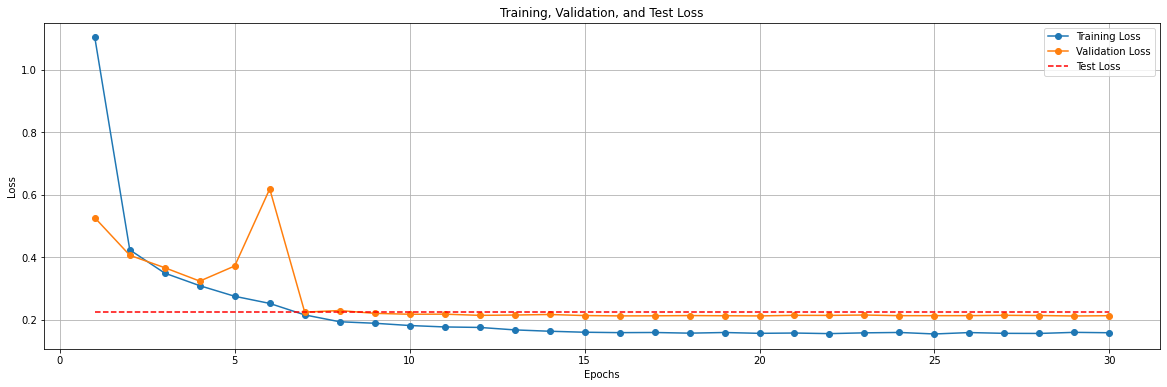

In [24]:
plot_loss(training_details , test_loss)

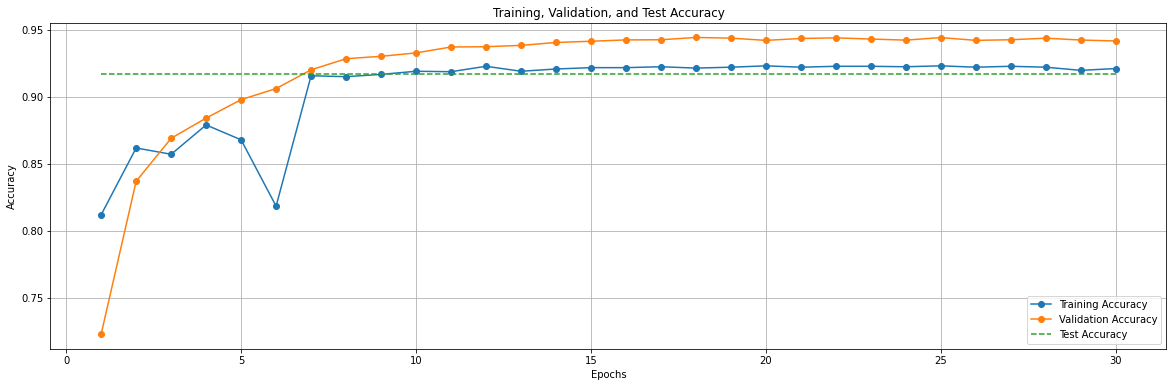

In [25]:
plot_accuracy(training_details , test_acc)

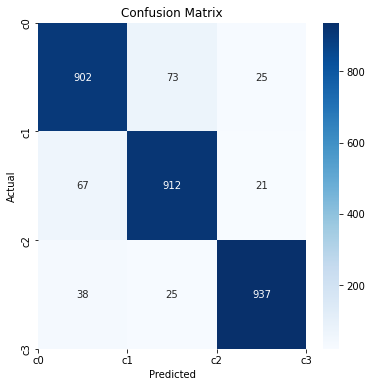

In [26]:
plot_conf_mat(y_true , y_pred)

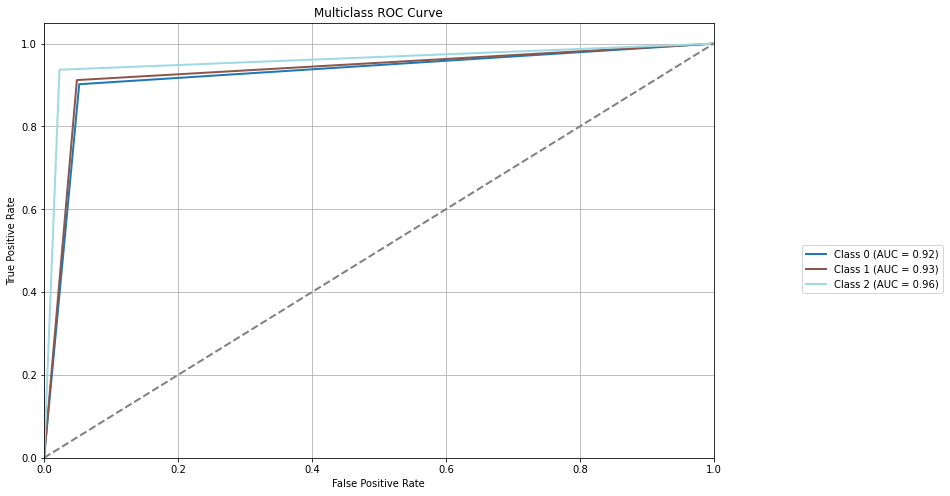

In [27]:
plot_roc_curve(y_true , y_pred)

In [20]:
# 2. Image augmentation

augmentation = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224), antialias=True), 
    T.RandomRotation(degrees=(0, 90)),
    T.RandomHorizontalFlip(p=0.3),
    T.ColorJitter(brightness=0.5, hue=0.1),
    T.ToTensor(),  
    T.ConvertImageDtype(torch.float32),   
])

In [21]:
class AugmentedDataset(Dataset):
    def __init__(self, original_dataset, transform, augment_factor=1):
        self.dataset = original_dataset
        self.transform = transform
        self.augment_factor = augment_factor  # How many times to augment each sample

    def __len__(self):
        return len(self.dataset) * self.augment_factor  

    def __getitem__(self, idx):
        original_idx = idx % len(self.dataset) 
        img, label = self.dataset[original_idx]
        img = self.transform(img)  
        return img, label

In [22]:
original_dataset = copy.deepcopy(dataset) 
augment_factor = 3  
augmented_dataset = AugmentedDataset(original_dataset, augmentation, augment_factor=augment_factor)

train_indices = list(range(len(augmented_dataset) // 3)) 
augmented_train_dataset = Subset(augmented_dataset, train_indices)

In [23]:
print("Original dataset size:", len(original_dataset))
print("Augmented dataset size:", len(augmented_dataset)) 
print("Subset size:", len(augmented_train_dataset))

Original dataset size: 30000
Augmented dataset size: 90000
Subset size: 30000


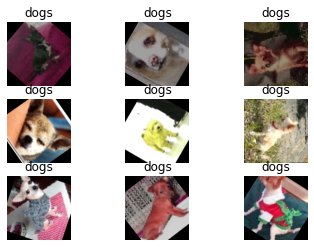

In [22]:
for i in range(9):
    img, label = augmented_train_dataset[i]
    plt.subplot(3,3,i+1)
    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.title(dataset.classes[int(label)])
    plt.axis('off')
plt.show()

In [24]:
batch_size = 128
train_loader = DataLoader(augmented_train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

vgg16_reg2 = VGG16_Reg(num_classes=3, init_method='he').to(device)
num_epochs = 30
optimizer = optim.SGD(vgg16_reg2.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=1)
BEST_MODEL_PATH = "best_model_vgg16_reg2.pth"

training_details = {}
training_details["train_acc"] = []
training_details["val_acc"] = []
training_details["train_loss"] = []
training_details["val_loss"] = [] 

In [25]:


train(
    model=vgg16_reg2,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    best_model_path=BEST_MODEL_PATH,
    scheduler = scheduler
    )

with open('training_details_vgg16_reg2.txt', 'w') as file:
    json.dump(training_details, file)




********************************************
Epoch :1
Learning Rate 0.01


235it [07:24,  1.89s/it]


Training loss 1.0489062342237918 | accuracy 0.6501333333333333 


100%|██████████| 24/24 [00:12<00:00,  1.85it/s]


validation loss 0.6242272071540356 | accuracy 0.7276094276094276 
Learning Rate 0.01
New best model saved at epoch 1 with validation accuracy 0.7276



********************************************
Epoch :2
Learning Rate 0.01


...

validation loss 0.2581209180255731 | accuracy 0.8922558922558923 
Learning Rate 1.0000000000000002e-07



********************************************
Epoch :30
Learning Rate 1.0000000000000002e-07


235it [07:29,  1.91s/it]


Training loss 0.3167103188469055 | accuracy 0.8766 


100%|██████████| 24/24 [00:12<00:00,  1.96it/s]

validation loss 0.25440990428129834 | accuracy 0.8952861952861952 
Learning Rate 1.0000000000000004e-08

Execution Time: 13690.819762 seconds


In [26]:
vgg16_reg2.load_state_dict(torch.load(BEST_MODEL_PATH))
y_true , y_pred , test_loss , test_acc  = evaluate(vgg16_reg2 , test_loader , criterion)

Loss : 0.28149329125881195 | Acc : 0.8943333333333333
Precision: 0.8941, Recall: 0.8943, F1 Score: 0.8942


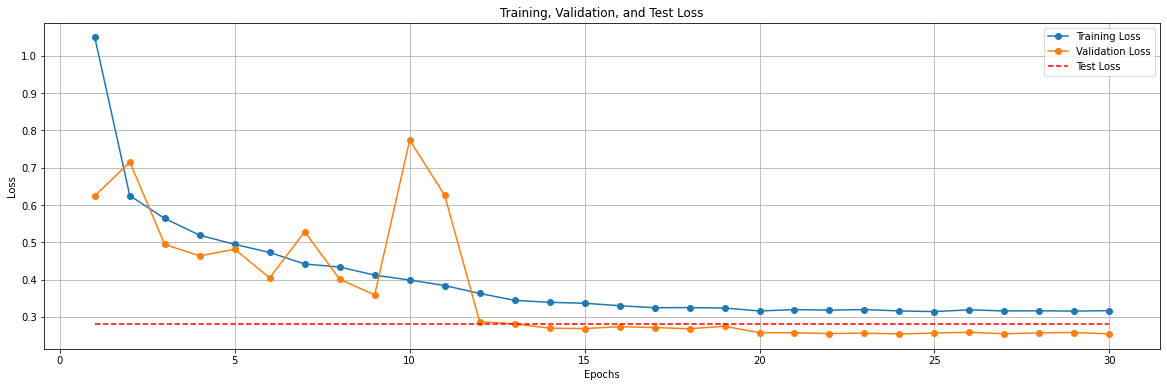

In [27]:
plot_loss(training_details , test_loss)

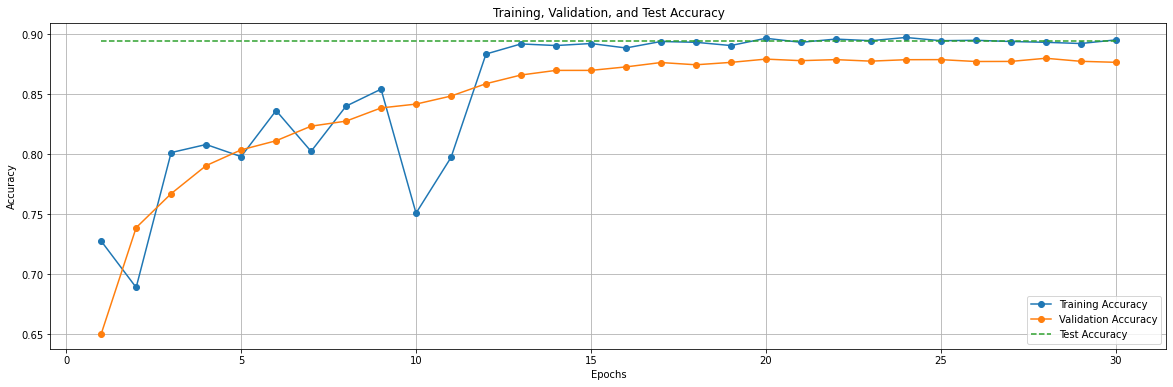

In [28]:
plot_accuracy(training_details , test_acc)

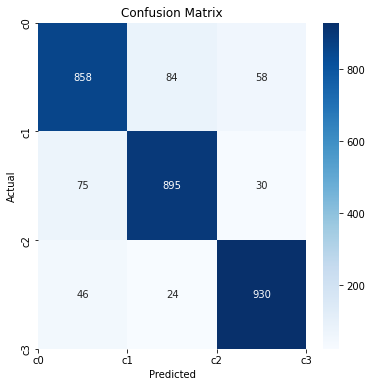

In [29]:
plot_conf_mat(y_true , y_pred)

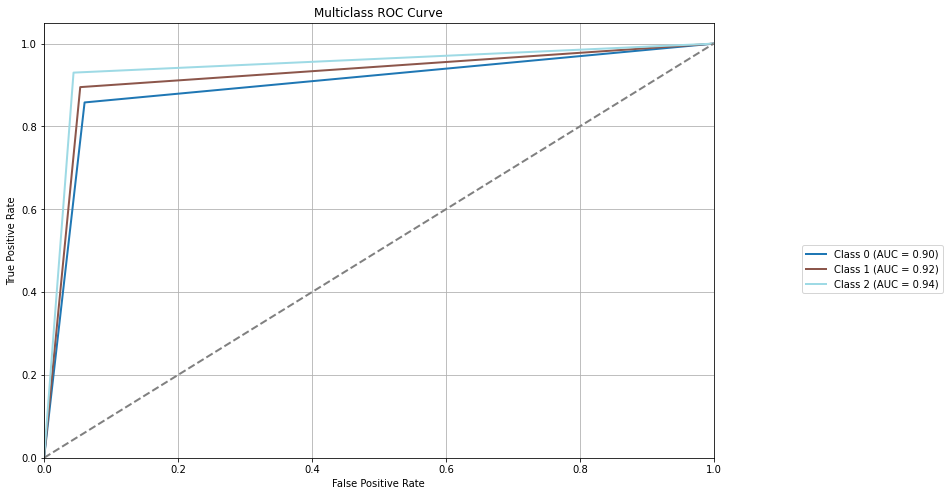

In [30]:
plot_roc_curve(y_true , y_pred)

In [24]:
# 3.Early stopping

batch_size = 128
train_loader = DataLoader(augmented_train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

vgg16_reg3 = VGG16_Reg(num_classes=3, init_method='he').to(device)
num_epochs = 30
optimizer = optim.SGD(vgg16_reg3.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=1)
BEST_MODEL_PATH = "best_model_vgg16_reg3.pth"

training_details = {}
training_details["train_acc"] = []
training_details["val_acc"] = []
training_details["train_loss"] = []
training_details["val_loss"] = [] 


In [32]:



train(
    model=vgg16_reg3,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    best_model_path=BEST_MODEL_PATH,
    scheduler = scheduler,
    early_stopping=True
    )

with open('training_details_vgg16_reg3.txt', 'w') as file:
    json.dump(training_details, file)




********************************************
Epoch :1
Learning Rate 0.01


235it [07:26,  1.90s/it]


Training loss 1.0271410513431467 | accuracy 0.6699 


100%|██████████| 24/24 [00:12<00:00,  1.92it/s]


validation loss 0.968460222085317 | accuracy 0.632996632996633 
Learning Rate 0.01
New best model saved at epoch 1 with validation accuracy 0.6330



********************************************
Epoch :2
Learning Rate 0.01


...

validation loss 0.39586876953641575 | accuracy 0.8319865319865319 
Learning Rate 0.0001



********************************************
Epoch :9
Learning Rate 0.0001


235it [07:27,  1.90s/it]


Training loss 0.4610805167796764 | accuracy 0.8164666666666667 


100%|██████████| 24/24 [00:12<00:00,  1.97it/s]

validation loss 0.3965494707226753 | accuracy 0.8316498316498316 
Learning Rate 1e-05
Early Stopping: Stop training because the learning rate has decreased 3 times.

Execution Time: 4151.300755 seconds


In [ ]:
with open('training_details/training_details_vgg16_reg3.txt', 'r') as file:
    training_details = json.load(file)

In [30]:
BEST_MODEL_PATH

'best_model_vgg16_reg3.pth'

In [31]:
vgg16_reg3.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=torch.device('cpu')))
y_true, y_pred, test_loss, test_acc = evaluate(vgg16_reg3, test_loader, criterion)

Loss : 0.477295412371556 | Acc : 0.8136666666666666
Precision: 0.8174, Recall: 0.8137, F1 Score: 0.8097


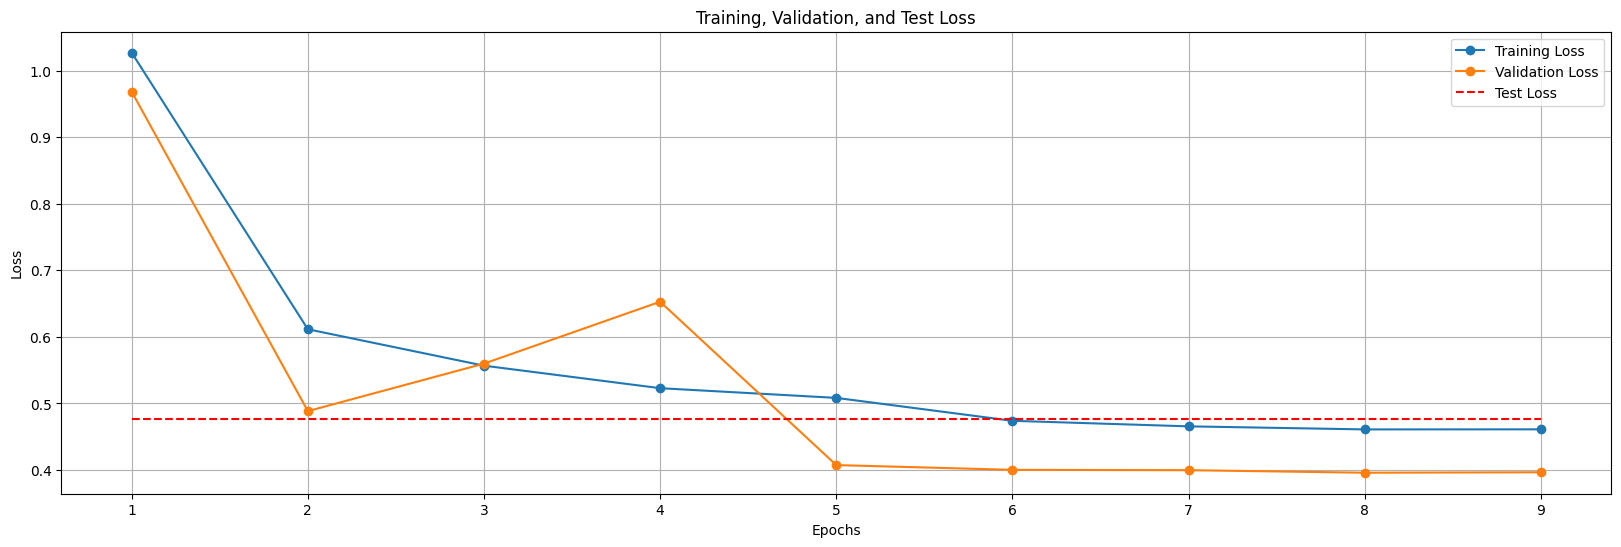

In [32]:
plot_loss(training_details , test_loss)

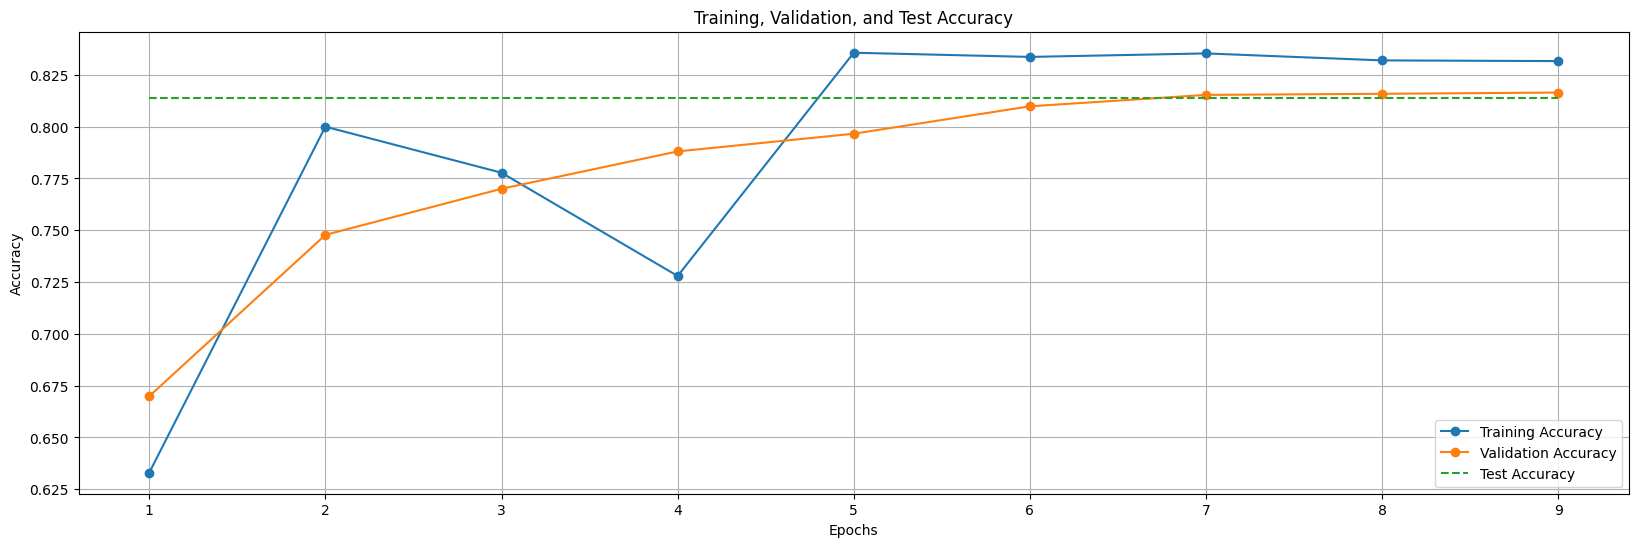

In [33]:
plot_accuracy(training_details , test_acc)

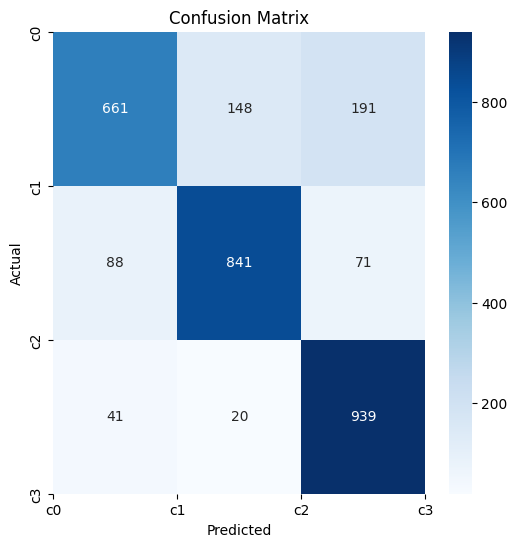

In [34]:
plot_conf_mat(y_true , y_pred)

/var/folders/27/45kf949539vdj0tjjp9nmw380000gn/T/ipykernel_81260/4002091186.py:101: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', n_classes)


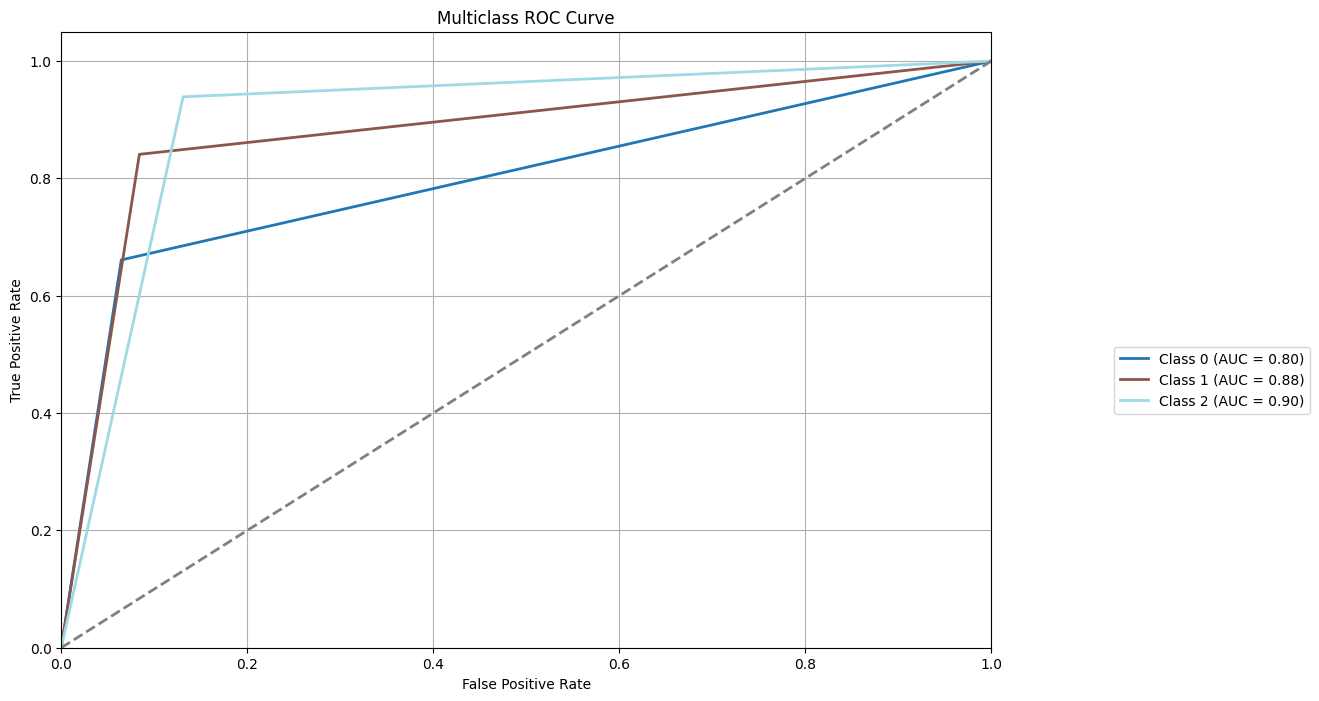

In [35]:
plot_roc_curve(y_true , y_pred)

Evaluation and analysis.

In [ ]:
with open("./training_details/training_details_vgg16_reg.txt", "r") as file:
    vgg16_details = json.load(file)

writer = SummaryWriter()

for epoch in range(len(vgg16_details['train_loss'])):
    writer.add_scalar('Loss/Train', vgg16_details['train_loss'][epoch], epoch)
    writer.add_scalar('Loss/Val', vgg16_details['val_loss'][epoch], epoch)
    writer.add_scalar('Accuracy/Train', vgg16_details['val_acc'][epoch], epoch)
    writer.add_scalar('Accuracy/Val', vgg16_details['train_acc'][epoch], epoch)

writer.close()

Experiment with Weight Initialization Strategies
- Convergence speed: A model with He initialization shows faster convergence in training loss and more stable accuracy curves.
- Learning curves: The Xavier-initialized model has a larger gap between training and validation curves, whereas the He-initialized model ahieves similar test results.
- He initialization helps the VGG model train more effectively.

Experiment with Optimizers
- Compared to Adam and RMSprop, SGD produces more stable convergence curves for both training and validation.
- In the confusion matrices for Adam and RMSprop, most samples end up classified into the same class.
- Overall, SGD achieves notably better performance in this setup.
- For deeper networks like VGG, SGD appears to be a more suitable optimizer.

Experiment with batch sizes
- Batch size 128 leads to more fluctuations during training, while a batch size of 64 shows smoother learning curves.
- Both batch sizes achive strong test performance.
- The larger the batch size, the longer training time per epoch. In this setting, a batch size of 128 took 2 minutes per epoch, while a batch size of 64 took 1:30.

Batch Normalization (BN)
- BN normalizes intermediate activations within each mini‐batch, keeping parameters on a similar scale and working well with various optimizers. It generally helps prevent overfitting in deep networks.
- As a result, the training loss drops more quickly and consistently.
- It also tends to yield smoother training curves with fewer spikes in loss or accuracy.

Image Augmentation
- Image augmentation applies random transformations to the training images. We used RandomRotation, RandomHorizontalFlip, and ColorJitter.
- It makes models to rely less on specific features, improving its generalization ability.
- Although the training process may show more fluctuations (because each batch can differ more dramatically), the overall performance is typically higher than without augmentation.

Early Stopping
- Early Stopping limits the number of training epochs.
- In this setup, training cut off if the validation accuracy failed to improve over three checks, causing the process to end after nine epochs.
- While the resulting learning curves are good, the model may have stopped training before reaching its best performance compared to other regularization methods.

<div style="display: inline-block;">
<h3>Train Loss</h3>
<img src="./tensorboard/vgg16_Loss_Train.svg" alt="Train Loss" width="300"/>
</div>
<div style="display: inline-block;">
<h3>Validation Loss</h3>
<img src="./tensorboard/vgg16_Loss_Val.svg" alt="Validation Loss" width="300"/>
</div>
<div style="display: inline-block;">
<h3>Train Accuracy</h3>
<img src="./tensorboard/vgg16_Accuracy_Train.svg" alt="Train Accuracy" width="300"/>
</div>
<div style="display: inline-block;">
<h3>Validation Accuracy</h3>
<img src="./tensorboard/vgg16_Accuracy_Val.svg" alt="Validation Accuracy" width="300"/>
</div>


misclassified images
- Several of misclassified images appear blurry or low‐resolution, making it difficult for the network to distinguish details.
- Bright, smooth backgrounds (floors in the first image) might resemble “food” textures to the CNN if it focuses more on overall color distribution or shape than on the object’s silhouette.

In [ ]:
vgg16_reg = VGG16_Reg(num_classes=3, init_method='he').to(device)
s_test_dataset = Subset(test_dataset, [i for i in range(320)])
s_test_loader = DataLoader(s_test_dataset, batch_size=32, shuffle=False)

vgg16_reg.load_state_dict(torch.load("./pth/best_model_vgg16_reg1.pth", map_location=torch.device('cpu')))
y_true , y_pred , test_loss , test_acc  = evaluate(vgg16_reg , s_test_loader , criterion)

misclassified_idx = [i for i, (true, pred) in enumerate(zip(y_true, y_pred)) if true != pred]

Loss : 0.21214504688978195 | Acc : 0.915625
Precision: 0.9213, Recall: 0.9156, F1 Score: 0.9159


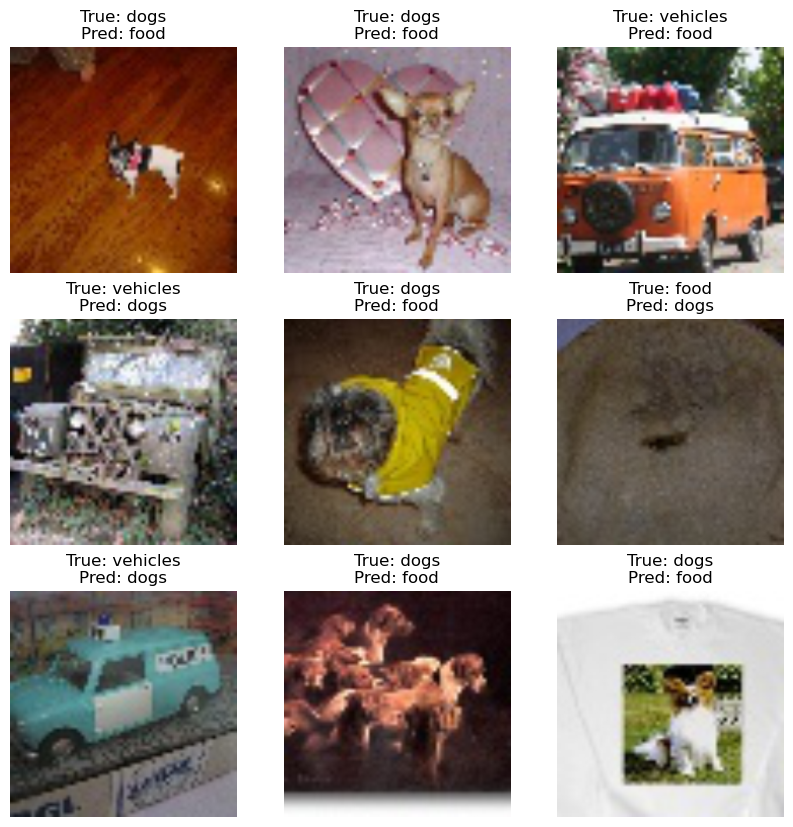

In [71]:
plt.figure(figsize=(10, 10))
for i, mis_idx in enumerate(misclassified_idx[:9]):
    img, label = s_test_dataset[mis_idx]
    true_label = dataset.classes[int(y_true[mis_idx])]
    pred_label = dataset.classes[int(y_pred[mis_idx])]
    plt.subplot(3,3,i+1)
    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')
plt.show()

## Step 3: Implementing ResNet

Implement residual blocks of ResNet.

In [73]:
class ResidualBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        self.expansion = 1

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = F.relu(out)
        return out



In [74]:
### ADD YOUR CODE HERE ###
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=1000):
        super(ResNet, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)
        
        self.init_weights()

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )
        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
    
    def init_weights(self, init_method='he'):
        if init_method is None:
            return
        for module in self.modules():
            if not isinstance(module, nn.Conv2d) and not isinstance(module, nn.Linear):
                continue
            if init_method == 'xavier':
                nn.init.xavier_uniform_(module.weight)
            elif init_method == 'he':
                nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')

def ResNet18(num_classes=3):
    return ResNet(ResidualBlock, [2, 2, 2, 2], num_classes)


model = ResNet18(num_classes=3)
channels = 3
w , h = 224 , 224
x = torch.randn(2, channels, w, h)  
output = model(x)
print("Output shape:", output.shape)

model = ResNet18(num_classes=3)
summary(model, input_size=( channels , w, h ) , device = 'cpu')


Output shape: torch.Size([2, 3])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
            Conv2d-7           [-1, 64, 56, 56]          36,864
       BatchNorm2d-8           [-1, 64, 56, 56]             128
     ResidualBlock-9           [-1, 64, 56, 56]               0
           Conv2d-10           [-1, 64, 56, 56]          36,864
      BatchNorm2d-11           [-1, 64, 56, 56]             128
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
    Re

Train the ResNet-18 model.

In [37]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

resnet18 = ResNet18(num_classes=3).to(device)
num_epochs = 10
learning_rate = 0.01
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet18.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=1)
BEST_MODEL_PATH = "best_model_resnet18_base.pth"

training_details = {}
training_details["train_acc"] = []
training_details["val_acc"] = []
training_details["train_loss"] = []
training_details["val_loss"] = []

In [27]:
num_epochs = 2
learning_rate = 0.01


#device = torch.device("mps" if torch.mps.is_available() else "cpu")
model = ResNet18(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
BEST_MODEL_PATH = "best_model_resnet18_base.pth"

device


device(type='mps')

In [46]:
device
learning_rate = 0.001
optimizer = optim.SGD(resnet18.parameters(), lr=learning_rate)

In [47]:
train(
    model=resnet18,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    best_model_path=BEST_MODEL_PATH
    )





********************************************
Epoch :1
Learning Rate 0.001


0it [00:00, ?it/s]

751it [04:29,  2.78it/s]


Training loss 0.01013677433837779 | accuracy 0.9972118185601332 


100%|██████████| 93/93 [00:10<00:00,  9.11it/s]


...

validation loss 0.29669169583595706 | accuracy 0.9326599326599326 
Learning Rate 0.001



********************************************
Epoch :10
Learning Rate 0.001


751it [06:18,  1.99it/s]


Training loss 0.0023381729534932465 | accuracy 0.9996670828131502 


100%|██████████| 93/93 [00:14<00:00,  6.23it/s]

validation loss 0.2892709226042072 | accuracy 0.931986531986532 
Learning Rate 0.001

Execution Time: 3374.153219 seconds


In [56]:
with open('training_details_resnet18_base.txt', 'w') as file:
    json.dump(training_details, file)

In [55]:
# Load the best model for testing
model.load_state_dict(torch.load(BEST_MODEL_PATH))

<All keys matched successfully>

In [49]:
y_true , y_pred , test_loss , test_acc  = evaluate(model , test_loader , criterion)     

Loss : 0.3300327436721071 | Acc : 0.916
Precision: 0.9162, Recall: 0.9160, F1 Score: 0.9161


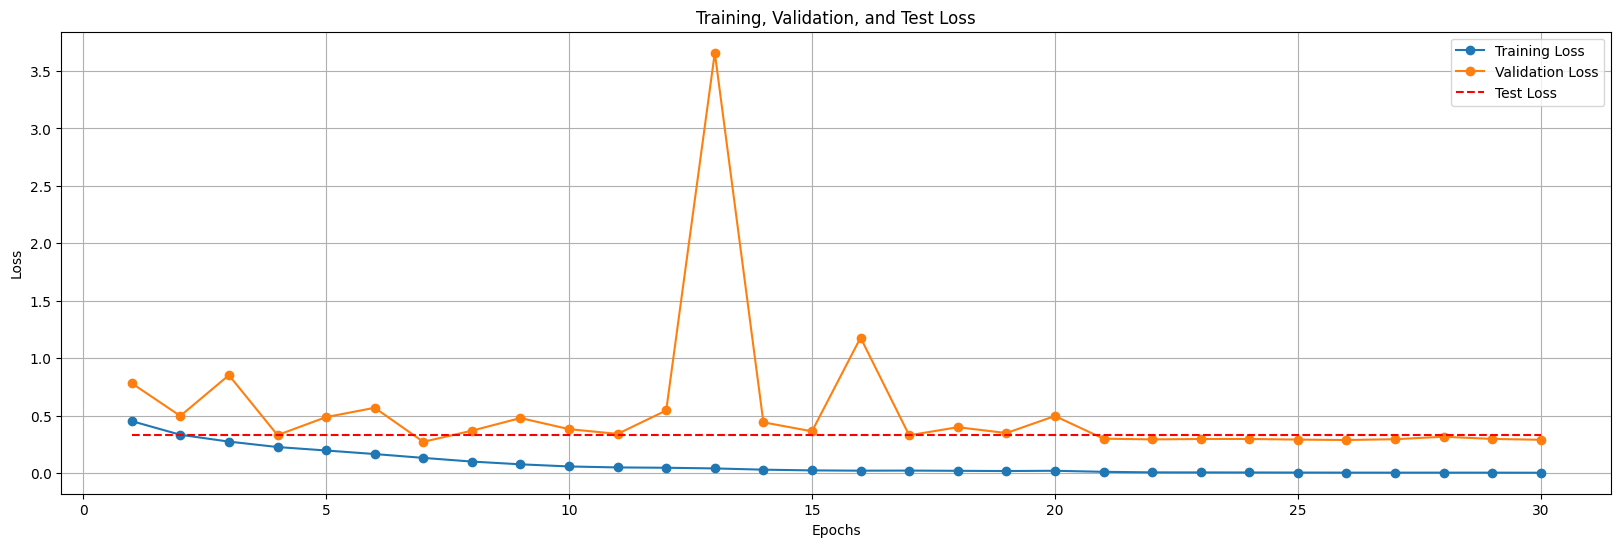

In [50]:
plot_loss(training_details , test_loss)

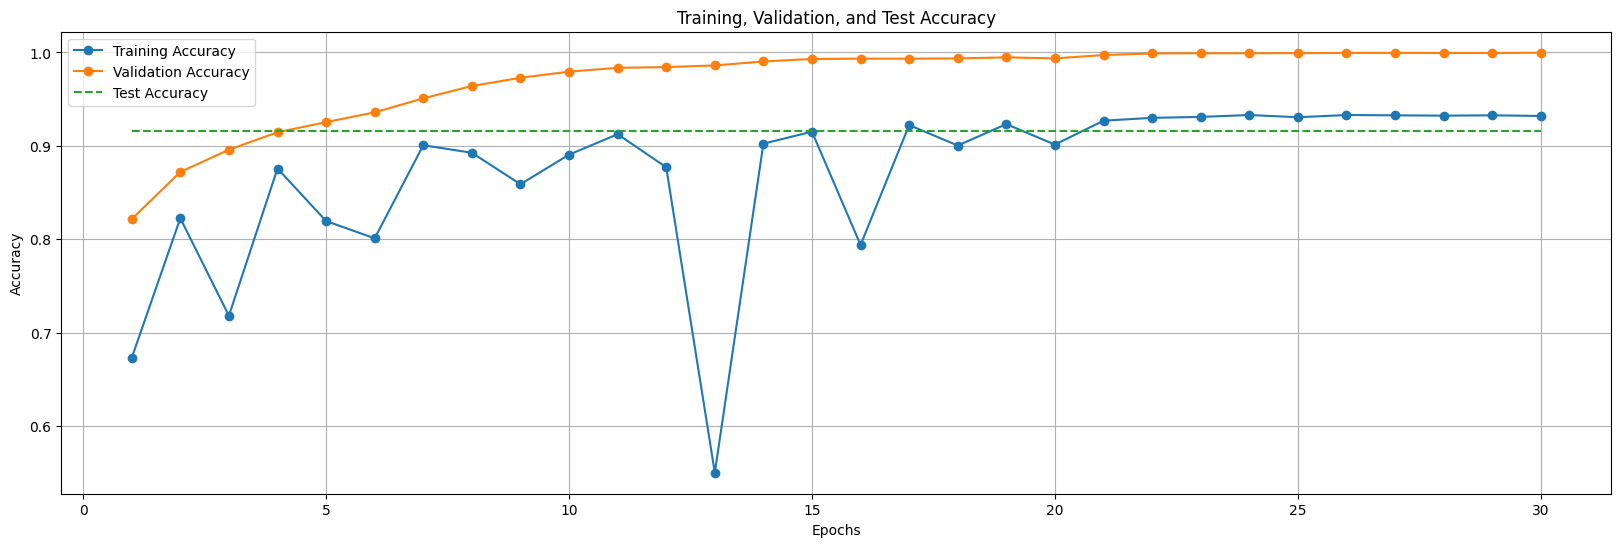

In [51]:
plot_accuracy(training_details , test_acc)

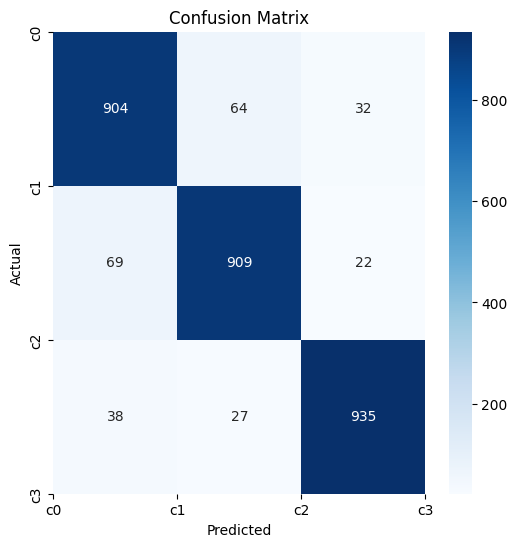

In [53]:
plot_conf_mat(y_true , y_pred)

/var/folders/27/45kf949539vdj0tjjp9nmw380000gn/T/ipykernel_37566/4002091186.py:101: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', n_classes)


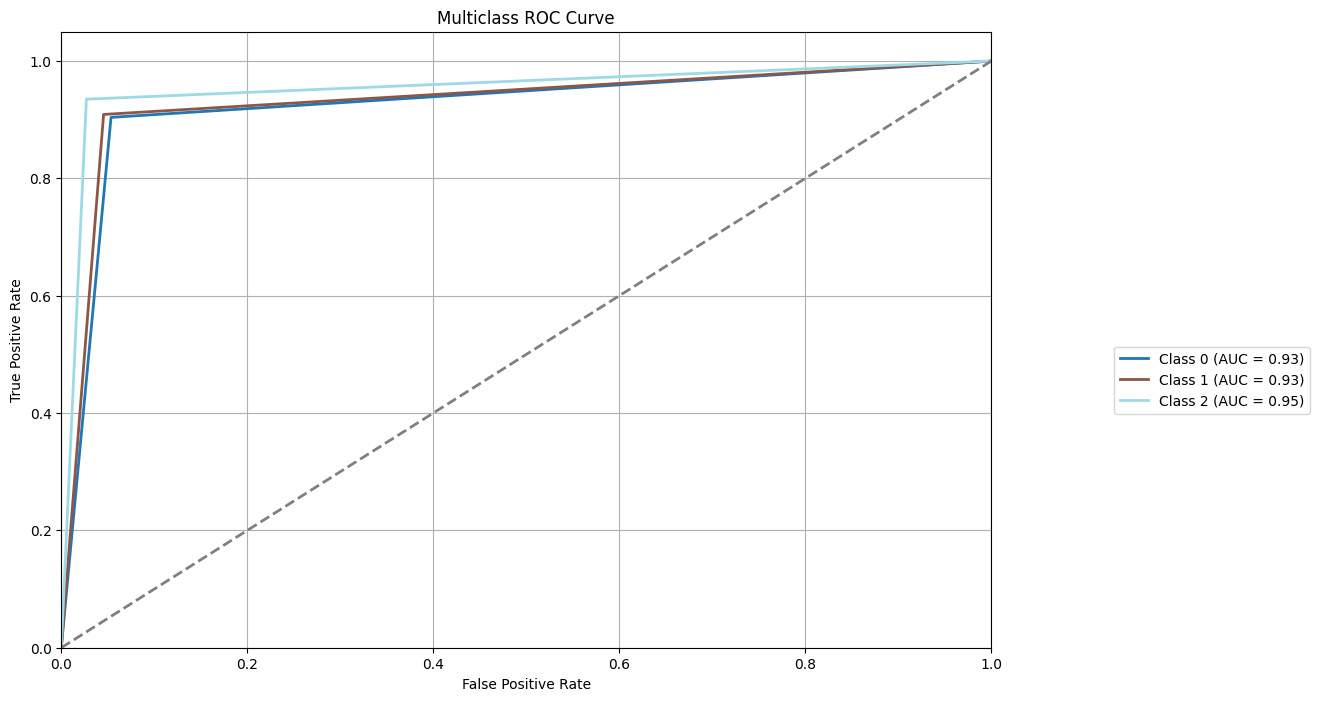

In [54]:
plot_roc_curve(y_true , y_pred)

In [21]:
augmentation = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224), antialias=True), 
    T.RandomRotation(degrees=(0, 90)),
    T.RandomHorizontalFlip(p=0.3),
    T.ColorJitter(brightness=0.5, hue=0.1),
    T.ToTensor(),  
    T.ConvertImageDtype(torch.float32),   
])

In [22]:
class AugmentedDataset(Dataset):
    def __init__(self, original_dataset, transform, augment_factor=1):
        self.dataset = original_dataset
        self.transform = transform
        self.augment_factor = augment_factor  # How many times to augment each sample

    def __len__(self):
        return len(self.dataset) * self.augment_factor  

    def __getitem__(self, idx):
        original_idx = idx % len(self.dataset) 
        img, label = self.dataset[original_idx]
        img = self.transform(img)  
        return img, label

In [25]:
original_dataset = copy.deepcopy(dataset) 
augment_factor = 3  
augmented_dataset = AugmentedDataset(original_dataset, augmentation, augment_factor=augment_factor)

train_indices = list(range(len(augmented_dataset) // 3)) 
augmented_train_dataset = Subset(augmented_dataset, train_indices)

In [26]:
print("Original dataset size:", len(original_dataset))
print("Augmented dataset size:", len(augmented_dataset)) 
print("Subset size:", len(augmented_train_dataset))

Original dataset size: 30000
Augmented dataset size: 90000
Subset size: 30000


Apply regularization techniques.

In [27]:
### ADD YOUR CODE HERE ###

batch_size = 128
train_loader = DataLoader(augmented_train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

resnet18_reg = ResNet18(num_classes=3).to(device)
num_epochs = 10
learning_rate = 0.01
optimizer = optim.SGD(resnet18_reg.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=1)
BEST_MODEL_PATH = "best_model_resnet18_reg.pth"

training_details = {}
training_details["train_acc"] = []
training_details["val_acc"] = []
training_details["train_loss"] = []
training_details["val_loss"] = []

In [35]:

train(
    model=resnet18_reg,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=num_epochs,
    optimizer=optimizer,
    loss_function=criterion,
    training_details=training_details,
    best_model_path=BEST_MODEL_PATH,
    scheduler = scheduler,
    early_stopping=True
    )

with open('training_details_resnet18_reg.txt', 'w') as file:
    json.dump(training_details, file)




********************************************
Epoch :1
Learning Rate 0.0001


235it [04:51,  1.24s/it]


Training loss 0.4431938313423319 | accuracy 0.8233 


100%|██████████| 24/24 [00:08<00:00,  2.88it/s]


validation loss 0.4112694226205349 | accuracy 0.8323232323232324 
Learning Rate 0.0001
New best model saved at epoch 1 with validation accuracy 0.8323



********************************************
Epoch :2
Learning Rate 0.0001


...

validation loss 0.4074862649043401 | accuracy 0.8313131313131313 
Learning Rate 1.0000000000000002e-06



********************************************
Epoch :7
Learning Rate 1.0000000000000002e-06


235it [04:51,  1.24s/it]


Training loss 0.43952757931770164 | accuracy 0.8255333333333333 


100%|██████████| 24/24 [00:08<00:00,  2.84it/s]

validation loss 0.41575396185119945 | accuracy 0.8282828282828283 
Learning Rate 1.0000000000000002e-07
Early Stopping: Stop training because the learning rate has decreased 3 times.

Execution Time: 2101.178963 seconds


Evaluation and analysis.

In [37]:
# Load the best model for testing
resnet18_reg.load_state_dict(torch.load(BEST_MODEL_PATH))

<All keys matched successfully>

In [38]:
y_true , y_pred , test_loss , test_acc  = evaluate(resnet18_reg , test_loader , criterion)     

Loss : 0.4227982709805171 | Acc : 0.8363333333333334
Precision: 0.8422, Recall: 0.8363, F1 Score: 0.8373


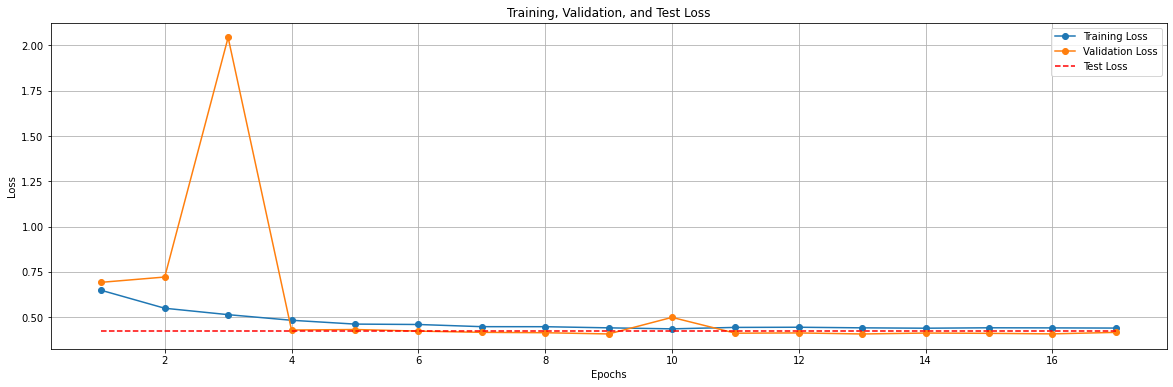

In [39]:
plot_loss(training_details , test_loss)

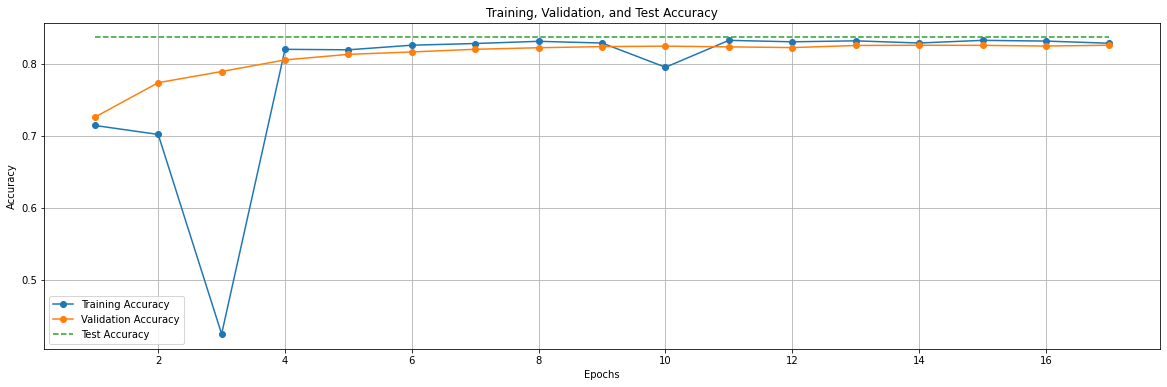

In [40]:
plot_accuracy(training_details , test_acc)

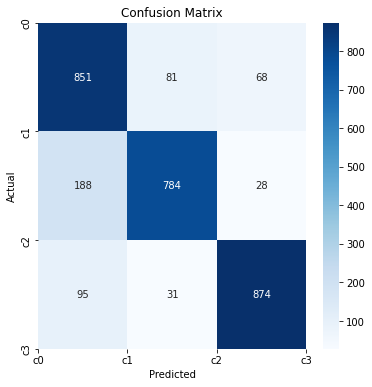

In [41]:
plot_conf_mat(y_true , y_pred)

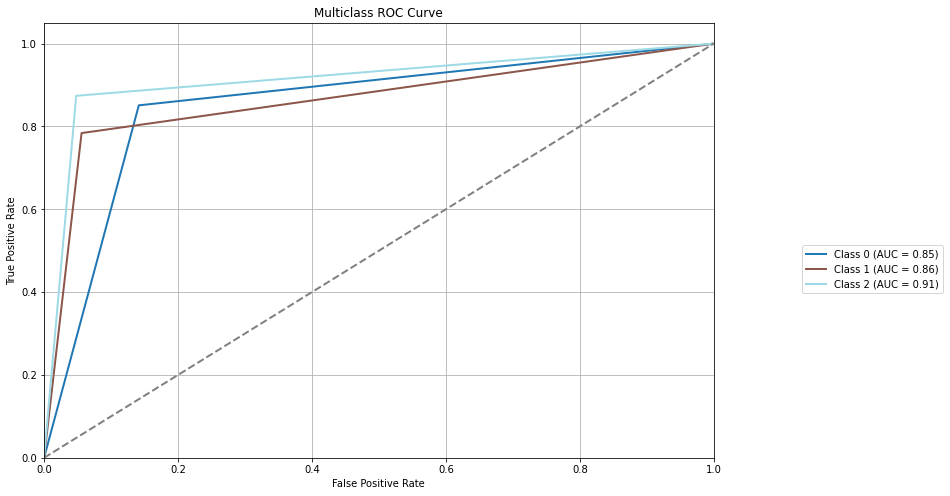

In [42]:
plot_roc_curve(y_true , y_pred)

In [29]:
with open("./training_details/training_details_resnet18_base.txt", "r") as file:
    resnet18_details = json.load(file)

writer = SummaryWriter()

for epoch in range(len(resnet18_details['train_loss'])):
    writer.add_scalar('Loss/Train', resnet18_details['train_loss'][epoch], epoch)
    writer.add_scalar('Loss/Val', resnet18_details['val_loss'][epoch], epoch)
    writer.add_scalar('Accuracy/Train', resnet18_details['val_acc'][epoch], epoch)
    writer.add_scalar('Accuracy/Val', resnet18_details['train_acc'][epoch], epoch)

writer.close()

<div style="display: inline-block;">
<h3>Train Loss</h3>
<img src="./tensorboard/resnet18_Loss_Train.svg" alt="Train Loss" width="300"/>
</div>
<div style="display: inline-block;">
<h3>Validation Loss</h3>
<img src="./tensorboard/resnet18_Loss_Val.svg" alt="Validation Loss" width="300"/>
</div>
<div style="display: inline-block;">
<h3>Train Accuracy</h3>
<img src="./tensorboard/resnet18_Accuracy_Train.svg" alt="Train Accuracy" width="300"/>
</div>
<div style="display: inline-block;">
<h3>Validation Accuracy</h3>
<img src="./tensorboard/resnet18_Accuracy_Val.svg" alt="Validation Accuracy" width="300"/>
</div>

Base ResNet18(with BN)
- Although the validation curves show occasional spikes, the training curves remain relatively stable, and the final test performance is quite high.
- The confusion matrix and ROC curve confirm strong classification across all classes, suggesting the model converged effectively overall.

ResNet18 applying regularization methods
- This setting applies image augmentation (e.g., flips, rotations) to the training data and uses early stopping (patience = 3) to combat overfitting.
- While there are some fluctuations in the training process, it stabilizes later.
- Because of the early‐stopping, the model may have halted training before reaching its absolute best performance compared to the base training.
- In exchange, these regularization methods often help models generalize better, though they require careful tuning to avoid prematurely stopping.
 

misclassified images
- Noise or blurriness can obscure distinct features that the model relies on.
- A cluster of animals/vehicles might appear to be a different class from certain angles or color patterns.

In [75]:
resnet18 = ResNet18(num_classes=3).to(device)
resnet18.load_state_dict(torch.load("./pth/best_model_resnet18_base.pth", map_location=torch.device('cpu')))
y_true , y_pred , test_loss , test_acc  = evaluate(resnet18 , s_test_loader , criterion)

misclassified_idx = [i for i, (true, pred) in enumerate(zip(y_true, y_pred)) if true != pred]

Loss : 0.039833975952933545 | Acc : 0.9875
Precision: 0.9875, Recall: 0.9875, F1 Score: 0.9875


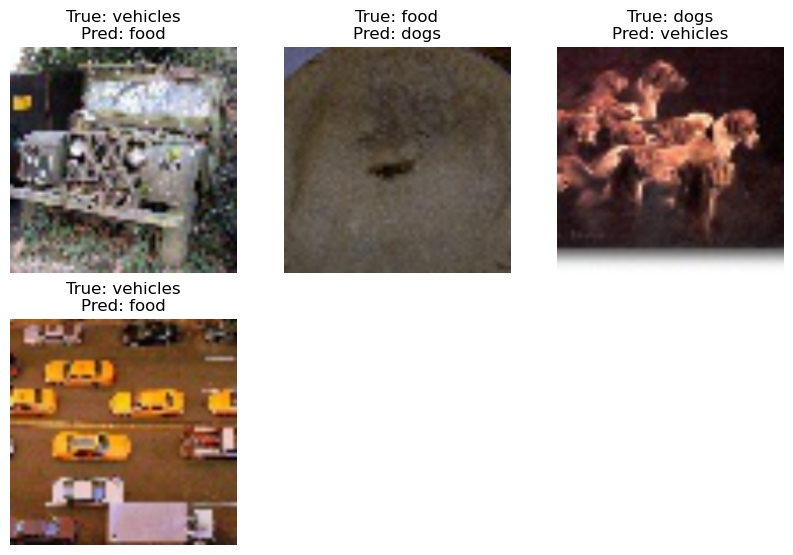

In [76]:
plt.figure(figsize=(10, 10))
for i, mis_idx in enumerate(misclassified_idx[:9]):
    img, label = s_test_dataset[mis_idx]
    true_label = dataset.classes[int(y_true[mis_idx])]
    pred_label = dataset.classes[int(y_pred[mis_idx])]
    plt.subplot(3,3,i+1)
    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')
plt.show()

Compare the performance of ResNet-18 and VGG-16
- Compared to VGG16, ResNet18 achieves more stable and higher performance in both training loss and accuracy. The residual connections allow training be more efficient and less prone to vanishing gradients. 
- As a result, ResNet18 converges more smoothly and reaches a better overall accuracy, highlighting the advantage of its design.

In [ ]:
def plot_extended(type, list_dic):
    colors = colormaps.get_cmap('tab20')
    epochs = max(len(list) for list in list_dic.values())
    plt.figure(figsize=(20, 6))
    for i, (model, loss) in enumerate(list_dic.items()):
        if(len(loss) < epochs):
            loss_extended = loss+[loss[-1] for _ in range(epochs-len(loss))]
            plt.plot(range(1, len(loss)+1), loss, label=f"{model} {type}", marker='o', color = colors(i))
            plt.plot(range(len(loss), epochs+1), loss_extended[len(loss)-1:], '--', label=f"{model} {type} (extended)", color = colors(i))
        else:
            plt.plot(range(1, epochs+1), loss, label=f"{model} {type}", marker='o', color = colors(i))

    plt.title(f'{list(list_dic.keys())} {type}')
    plt.xlabel('Epochs')
    plt.ylabel(f"{type}")
    plt.legend()
    plt.grid()
    plt.xticks()
    plt.show()

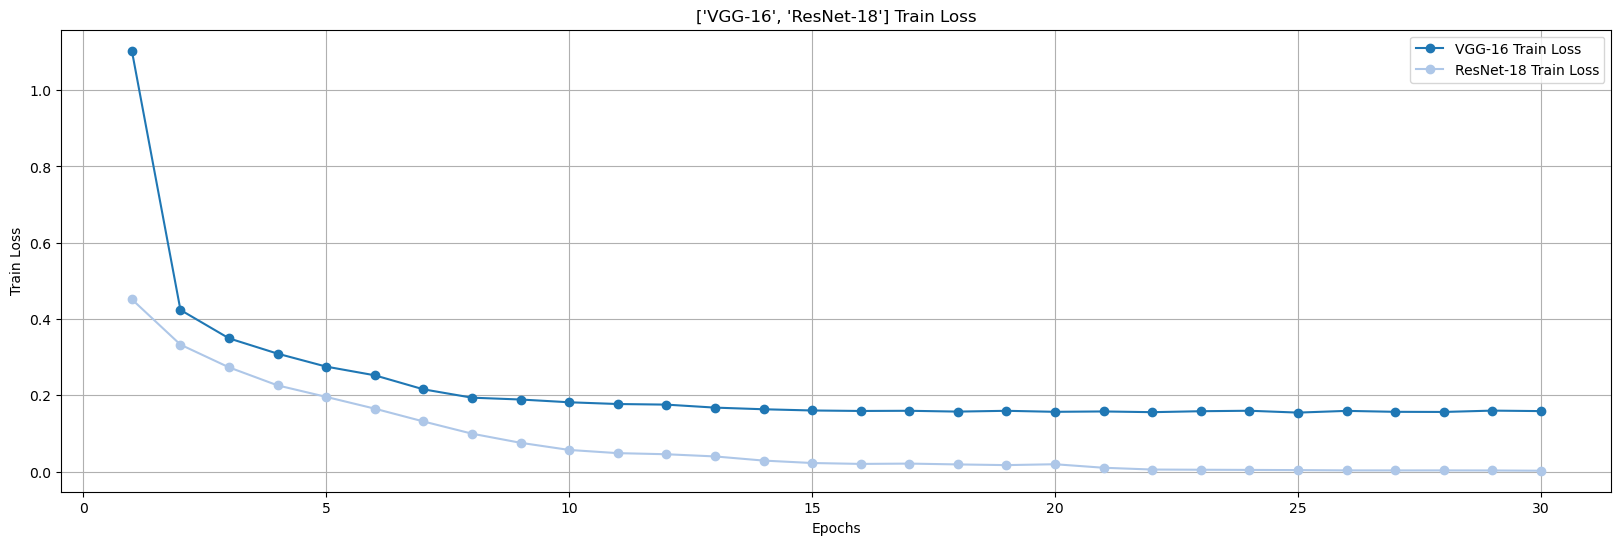

In [33]:
loss_lists = {"VGG-16": vgg16_details['train_loss'], "ResNet-18": resnet18_details['train_loss']}
plot_extended(type="Train Loss", list_dic = loss_lists)

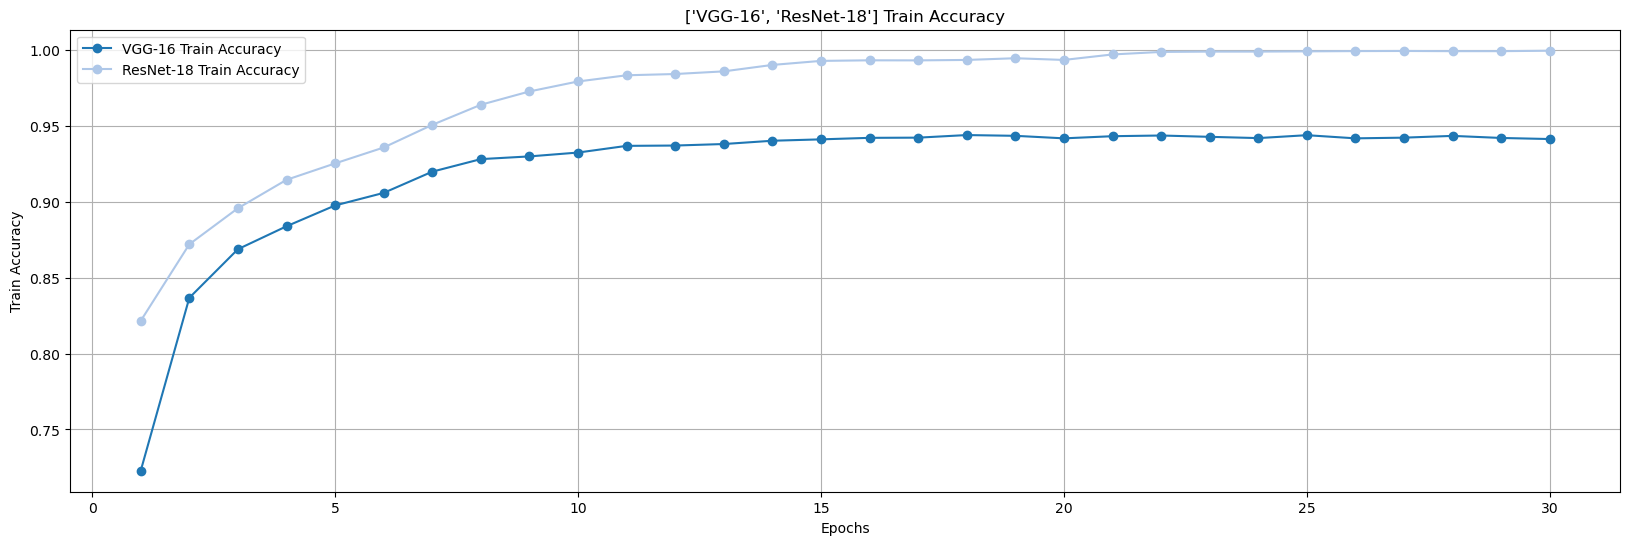

In [34]:
acc_lists = {"VGG-16": vgg16_details['val_acc'], "ResNet-18": resnet18_details['val_acc']}
plot_extended(type="Train Accuracy", list_dic = acc_lists)

6. Save the weights of the trained network.

## Step 4: Discussion and conclusion

### The theoretical concepts behind VGG and ResNet
VGG introduced the use of stacked blocks of small 3 × 3 convolutions, each followed by pooling layers. By employing smaller kernels, the model effectively captures complex features while controlling parameter growth (compared to large‐kernel designs).
VGG increase the network depth compared to earlier CNNs (e.g., AlexNet). This deeper structure significantly boosts representational power but can be more prone to vanishing gradients without additional techniques such as careful initialization or batch normalization.

ResNet uses Residual Blocks that add an input directly to its subsequent output. This effectively bypasses certain layers and preserves low‐level information.
These residual connections help combat vanishing or exploding gradients in very deep networks, allowing signals to flow freely across layers. As a result, ResNets can be trained with many more layers while maintaining accuracy.

### Impact of regularization and optimization techniques
In previous experiments, we applied a number of regularization and optimization techniques-batch normalization, image augmentation, early stopping, and various optimizers.

Batch Normalization (BN)
- BN normalizes intermediate activations within each mini‐batch, keeping parameters on a similar scale and working well with various optimizers. It generally helps prevent overfitting in deep networks.
- It helps the training loss drop more quickly and consistently.
- It also tends to yield smoother training curves in loss and accuracy.
- It reduced overfitting, for deep networks like VGG and ResNet

Optimizers
- SGD (with momentum) often produced more stable convergence curves. This was especially true for deeper models, such as VGG, which benefited from the more controlled gradient updates.
- Adam and RMSprop sometimes showed faster initial convergence but could get stuck in suboptimal modes if hyperparameters (e.g., learning rate) were not properly tuned.

Image Augmentation
- Image augmentation applies random transformations to the training images. We used random rotation, horizontal flipping, and color jitter.
- It makes models to rely less on specific features, improving its generalization ability.
- Although the training process may show more fluctuations (because each batch may vary), the overall performance is higher than without augmentation.

Early Stopping
- Early Stopping limits the number of training epochs.
- In this setup, training cut off if the validation accuracy failed to improve over three checks (patience).
- While the resulting learning curves are good, the model might stop too soon before reaching its best performance. Proper tuning is important.

### Result Analysis
VGG tends to show smooth learning curves when properly initialized (e.g., He initialization). In ResNet, residual connections allowed deeper stacking of layers with less vanishing gradients.

ResNet‑18 typically reached comparable or superior accuracy with fewer parameters than VGG‑16, thanks to residual connections. VGG‑16 can still perform strongly, but is more prone to training slowdown or overfitting without techniques like augmentation and BN.

Regularization and optimization techniques leads to achieve higher accuracies and strong confusion matrix. Proper hyperparameters also help to be converged faster and more reliably.

### Findings
VGG‑16 uses simple 3×3 convolutions stacked deeply, which is computationally heavy. ResNet‑18 utilizes residual connections to preserve gradients through layers.

Residual connections help avoid the vanishing gradient problem. And it achieves faster convergence and better generalization with fewer parameters.

References
<ul>
    <li>Part I, Step 1 is based on the CSE 676 Deep Learning Assignment 0 submission by Heeju Hwang</li>
    <li>https://pytorch.org/docs/stable/data.html</li>
    <li>https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html</li>
    <li>https://drlee.io/mastering-train-test-split-with-stratification-on-the-cooperunion-dataset-611e305aa46d</li>
    <li>Part I, Step 2 is based on the CSE 676 Deep Learning Quiz 3</li>
    <li>Part I, Step 2 is based on Fall 2024 Machine Learning Assignment 2 by Heeju Hwang</li>
    <li>https://www.geeksforgeeks.org/how-to-iterate-over-layers-in-pytorch/</li>
    <li>https://pytorch.org/vision/main/transforms.html</li>
    <li>https://pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html</li>
    <li>https://pytorch.org/docs/stable/tensorboard.html</li>
    <li>Part I, Step 2 is based on <a href="https://d2l.ai/index.html">Dive into Deep Learning</a> 5.5.3., 8.5, 14.1 </li>
    <li>Part I, Step 4 is based on <a href="https://d2l.ai/index.html">Dive into Deep Learning</a> 8.2, 8.6, 12.1</li>
</ul>